In [ ]:
## TODO
# add thermostability features from GINKGO competition
# add CDR3 length !!
# explore this: 
# Dataset: ginkgo_unified_target_AC_SINS_pH7_4
# Rows (with valid target): 244, Features: 103

# Columns that are 100% NaN (1): ['inter_chain_buried_sasa']

# Columns with at least one NaN (2):
# inter_chain_buried_sasa            1.000000
# ratio_salt_bridges_CDR_to_total    0.852459

# Rows with at least one NaN in X: 244 / 244

# GINKGO dataset!!!!!!!!
# store datasets in a dict

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import glob
import os
pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore')

# Utils

In [2]:
def encode_feature_categoricals(df, target_col="target"):
    """
    Convert categorical feature_* columns to ordinal codes.
    - Only touches columns starting with 'feature_'.
    - Skips ID and target columns.
    """
    id_cols = {
        "structure_id", "base", "heavy", "light",
        "dataset", "name", "antibody_name", "index",
    }
    from pandas.api.types import is_categorical_dtype, is_object_dtype

    for col in df.columns:
        if not str(col).startswith("feature_"):
            continue
        if col in id_cols or col == target_col:
            continue
        if is_object_dtype(df[col]) or is_categorical_dtype(df[col]):
            # Ordinal codes: 0..K-1; missing becomes NaN
            cat = df[col].astype("category")
            codes = cat.cat.codes.replace(-1, np.nan)
            df[col] = codes
    return df

In [3]:
from collections import defaultdict


def find_highly_correlated_feature_pairs_across_datasets(
    merged_df,
    dataset_col: str = "dataset",
    corr_threshold: float = 0.8,
    min_dataset_fraction: float = 0.9,
    min_samples: int = 3,
):
    """Find feature-feature pairs that are highly correlated in most datasets.

    For each dataset, compute Pearson and Spearman correlations between all
    feature pairs. If a pair has |r| and |ρ| >= `corr_threshold` in more than
    `min_dataset_fraction` of datasets (where both features have >= `min_samples`
    non-NaN values and are non-constant), the pair is reported.
    """
    if merged_df is None or merged_df.empty:
        print("merged_df is empty; nothing to compute.")
        return pd.DataFrame(
            columns=[
                "feature1",
                "feature2",
                "n_datasets",
                "fraction_datasets",
                "mean_abs_pearson",
                "mean_abs_spearman",
            ]
        )

    if dataset_col not in merged_df.columns:
        print(f"Column '{dataset_col}' not found in merged_df; cannot group by dataset.")
        return pd.DataFrame(
            columns=[
                "feature1",
                "feature2",
                "n_datasets",
                "fraction_datasets",
                "mean_abs_pearson",
                "mean_abs_spearman",
            ]
        )

    # Reuse the same idea of feature selection as in the target-correlation cell
    exclude_cols = [
        "antibody_id",
        "residue_number",
        "n_total_rows",
        "n_filtered_rows",
        "n_beta_sheet_rows",
        "n_exposed_rows",
    ]
    id_cols = {
        "structure_id",
        "base",
        "heavy",
        "light",
        "dataset",
        "name",
        "antibody_name",
        "target",  # unified target column (all source targets are target_*)
    }

    numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        feature_cols = [
            col
            for col in numeric_cols
            if col not in exclude_cols and col not in {dataset_col}
        ]
    else:
        feature_cols = [
            col
            for col in merged_df.columns
            if col not in exclude_cols and col not in id_cols and col != dataset_col
        ]

    # Exclude dataset and any target column (target or target_*)
    feature_cols = [
        col
        for col in feature_cols
        if col != dataset_col and not (str(col).startswith("target"))
    ]

    if len(feature_cols) < 2:
        print("Not enough feature columns to compute feature-feature correlations.")
        return pd.DataFrame(
            columns=[
                "feature1",
                "feature2",
                "n_datasets",
                "fraction_datasets",
                "mean_abs_pearson",
                "mean_abs_spearman",
            ]
        )

    datasets = merged_df[dataset_col].dropna().unique().tolist()
    n_datasets_total = len(datasets)
    if n_datasets_total == 0:
        print("No datasets found in merged_df.")
        return pd.DataFrame(
            columns=[
                "feature1",
                "feature2",
                "n_datasets",
                "fraction_datasets",
                "mean_abs_pearson",
                "mean_abs_spearman",
            ]
        )

    pair_stats = {}  # (f1, f2) -> {"datasets": set, "pearson": [], "spearman": []}

    for ds in datasets:
        ds_df = merged_df[merged_df[dataset_col] == ds]
        if ds_df.empty:
            continue

        # Work only with numeric data for this dataset
        ds_numeric = ds_df[feature_cols].apply(pd.to_numeric, errors="coerce")

        for i in range(len(feature_cols)):
            f1 = feature_cols[i]
            x = ds_numeric[f1]
            if x.notna().sum() < min_samples or x.nunique(dropna=True) < 2:
                continue

            for j in range(i + 1, len(feature_cols)):
                f2 = feature_cols[j]
                y = ds_numeric[f2]
                if y.notna().sum() < min_samples or y.nunique(dropna=True) < 2:
                    continue

                pair_df = pd.concat([x, y], axis=1).dropna()
                if len(pair_df) < min_samples:
                    continue

                try:
                    r_pearson, _ = pearsonr(pair_df[f1], pair_df[f2])
                    r_spearman, _ = spearmanr(pair_df[f1], pair_df[f2])
                except Exception:
                    continue

                if not np.isfinite(r_pearson) or not np.isfinite(r_spearman):
                    continue

                if (
                    abs(r_pearson) >= corr_threshold
                    and abs(r_spearman) >= corr_threshold
                ):
                    key = tuple(sorted((f1, f2)))
                    if key not in pair_stats:
                        pair_stats[key] = {
                            "datasets": set(),
                            "pearson": [],
                            "spearman": [],
                        }
                    if ds not in pair_stats[key]["datasets"]:
                        pair_stats[key]["datasets"].add(ds)
                        pair_stats[key]["pearson"].append(r_pearson)
                        pair_stats[key]["spearman"].append(r_spearman)

    results = []
    for (f1, f2), stats_dict in pair_stats.items():
        n_ds = len(stats_dict["datasets"])
        frac = n_ds / n_datasets_total if n_datasets_total > 0 else 0.0
        if frac >= min_dataset_fraction:
            results.append(
                {
                    "feature1": f1,
                    "feature2": f2,
                    "n_datasets": n_ds,
                    "fraction_datasets": frac,
                    "mean_abs_pearson": float(np.mean(np.abs(stats_dict["pearson"]))),
                    "mean_abs_spearman": float(np.mean(np.abs(stats_dict["spearman"]))),
                }
            )

    if not results:
        print(
            f"No feature pairs with |r| and |ρ| ≥ {corr_threshold} "
            f"in more than {min_dataset_fraction * 100:.1f}% of datasets "
            f"(min_samples={min_samples})."
        )
        return pd.DataFrame(
            columns=[
                "feature1",
                "feature2",
                "n_datasets",
                "fraction_datasets",
                "mean_abs_pearson",
                "mean_abs_spearman",
            ]
        )

    results_df = pd.DataFrame(results).sort_values(
        ["fraction_datasets", "mean_abs_pearson"], ascending=[False, False]
    )
    print(
        f"Feature pairs with |r| and |ρ| ≥ {corr_threshold} "
        f"in more than {min_dataset_fraction * 100:.1f}% of datasets "
        f"(min_samples={min_samples}, total_datasets={n_datasets_total}):"
    )
    print(results_df)

    return results_df

In [4]:
# Debug: whole-protein columns (first row of each _results CSV) – check they are in merged_df
WHOLE_PROTEIN_COLS = [
    "ripley_k_negative", "ripley_k_positive", "ripley_k_hydrophobic", "ripley_k_polar",
    "psh_all_surface_exposed", "psh_cdr_vicinity", "ppc_all_surface_exposed", "ppc_cdr_vicinity",
    "pnc_all_surface_exposed", "pnc_cdr_vicinity",
    "dipole_moment_magnitude", "largest_hbond_component_size", "net_charge", "protein_pi", "scm_score",
    "net_charge_pH4", "net_charge_pH5", "net_charge_pH6", "net_charge_pH7",
    "net_charge_pH8", "net_charge_pH9", "net_charge_pH10",
]
if "merged_df" in dir() and not merged_df.empty:
    present = [c for c in WHOLE_PROTEIN_COLS if c in merged_df.columns]
    missing = [c for c in WHOLE_PROTEIN_COLS if c not in merged_df.columns]
    print("Whole-protein columns (from first row of each result CSV):")
    print(f"  Present in merged_df: {len(present)}/{len(WHOLE_PROTEIN_COLS)}")
    if missing:
        print(f"  Missing: {missing}")
    # Non-null counts for net_charge* (often the ones that vary by pipeline)
    net_cols = [c for c in present if c.startswith("net_charge")]
    if net_cols:
        print("  Non-null counts for net_charge*:")
        for c in net_cols:
            print(f"    {c}: {merged_df[c].notna().sum()}/{len(merged_df)}")
else:
    print("Run the loading cell above first (merged_df not available).")

Run the loading cell above first (merged_df not available).


In [5]:
def _bh_adjust(pvals):
    """Benjamini-Hochberg FDR adjustment. pvals: array-like. NaNs are preserved (not used in adjustment)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    valid = np.isfinite(p)
    if not np.any(valid):
        return p
    p_valid = p[valid]
    n = len(p_valid)
    order = np.argsort(p_valid)
    p_sorted = p_valid[order]
    ratios = n * p_sorted / np.arange(1, n + 1)
    adj_sorted = np.minimum(1, np.minimum.accumulate(ratios[::-1])[::-1])
    rank_of_original = np.argsort(order)
    out[valid] = adj_sorted[rank_of_original]
    return out

def calculate_correlations_and_plot(merged_df, target_col, p_threshold=0.05, fdr_alpha=0.05, use_fdr=True, normalize=False):
    # Filter out rows where target is NaN/invalid so we only correlate on a valid target set (e.g. Jain merged has NaNs per target)
    merged_df = merged_df.copy()
    merged_df[target_col] = pd.to_numeric(merged_df[target_col], errors="coerce")
    n_before = len(merged_df)
    merged_df = merged_df.dropna(subset=[target_col])
    n_after = len(merged_df)
    if n_before > n_after:
        print(f"Dropped {n_before - n_after} rows with NaN/invalid target (using {n_after} for correlations).")
    exclude_cols = ['antibody_id', 'residue_number', 'n_total_rows', 'n_filtered_rows', 'n_beta_sheet_rows', 'n_exposed_rows']
    id_cols = {'structure_id', 'base', 'heavy', 'light', 'dataset', 'name', 'antibody_name'}
    numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) > 0:
        feature_cols = [col for col in numeric_cols if col not in exclude_cols and col not in id_cols and col != target_col and not str(col).startswith("target")]
    else:
        feature_cols = [col for col in merged_df.columns if col not in exclude_cols and col not in id_cols and col != target_col and not str(col).startswith("target")]
    correlations = []
    
    for col in feature_cols:
        data = merged_df[[target_col, col]].copy()
        data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
        data[col] = pd.to_numeric(data[col], errors='coerce')
        data = data.dropna()
        if len(data) < 3:
            continue
        
        if normalize:
            target_min = data[target_col].min()
            target_max = data[target_col].max()
            target_range = target_max - target_min
            if target_range > 0:
                target_norm = (data[target_col] - target_min) / target_range
            else:
                target_norm = data[target_col]
            
            feature_min = data[col].min()
            feature_max = data[col].max()
            feature_range = feature_max - feature_min
            if feature_range > 0:
                feature_norm = (data[col] - feature_min) / feature_range
            else:
                feature_norm = data[col]
            
            spearman_r, spearman_p = spearmanr(target_norm, feature_norm)
        else:
            spearman_r, spearman_p = spearmanr(data[target_col], data[col])
        
        correlations.append({
            'feature': col,
            'spearman_r': spearman_r,
            'spearman_p': spearman_p,
            'n_samples': len(data)
        })
    
    corr_df = pd.DataFrame(correlations)
    if corr_df.empty:
        corr_df = pd.DataFrame(columns=['feature', 'spearman_r', 'spearman_p', 'spearman_p_adj', 'n_samples'])
        significant = corr_df.copy()
    else:
        if use_fdr:
            corr_df['spearman_p_adj'] = _bh_adjust(corr_df['spearman_p'].values)
            significant = corr_df[corr_df['spearman_p_adj'] < fdr_alpha].copy()
        else:
            corr_df['spearman_p_adj'] = corr_df['spearman_p'].values
            significant = corr_df[corr_df['spearman_p'] < p_threshold].copy()
    
    print(f"Total features tested: {len(corr_df)}")
    print(f"Significant (raw p < {p_threshold}): {(corr_df['spearman_p'] < p_threshold).sum()}")
    if use_fdr:
        print(f"Significant after FDR correction (adj p < {fdr_alpha}): {len(significant)}")
    else:
        print(f"Significant (no FDR): {len(significant)}")
    if normalize:
        print("Note: Features were min-max normalized before correlation calculation")
    print(f"\nTop correlations by absolute Spearman r ({'FDR-significant only' if use_fdr else 'raw p < ' + str(p_threshold)}):")
    if len(significant) > 0:
        sig = significant.copy()
        sig["spearman_r"] = pd.to_numeric(sig["spearman_r"], errors="coerce")
        sig = sig.dropna(subset=["spearman_r"])
        if len(sig) > 0:
            cols = ["feature", "spearman_r", "spearman_p", "spearman_p_adj"]
            print(sig.nlargest(10, "spearman_r", keep="all")[[c for c in cols if c in sig.columns]])
        else:
            print("(none)")
    else:
        print("(no significant correlations)")
    
    if len(significant) > 0:
        n_plots = len(significant)
        n_cols = 3
        n_rows = (n_plots + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        axes = np.atleast_1d(axes).flatten()
        
        for plot_idx, (idx, row) in enumerate(significant.iterrows()):
            ax = axes[plot_idx]
            data = merged_df[[target_col, row['feature']]].copy()
            data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
            data[row['feature']] = pd.to_numeric(data[row['feature']], errors='coerce')
            data = data.dropna()
            
            if normalize:
                target_min = data[target_col].min()
                target_max = data[target_col].max()
                target_range = target_max - target_min
                if target_range > 0:
                    target_norm = (data[target_col] - target_min) / target_range
                else:
                    target_norm = data[target_col]
                
                feature_min = data[row['feature']].min()
                feature_max = data[row['feature']].max()
                feature_range = feature_max - feature_min
                if feature_range > 0:
                    feature_norm = (data[row['feature']] - feature_min) / feature_range
                else:
                    feature_norm = data[row['feature']]
                
                ax.scatter(feature_norm, target_norm, alpha=0.6)
                
                z = np.polyfit(feature_norm, target_norm, 1)
                p = np.poly1d(z)
                # ax.plot(feature_norm, p(feature_norm), "r--", alpha=0.8)
            else:
                ax.scatter(data[row['feature']], data[target_col], alpha=0.6)
                
                z = np.polyfit(data[row['feature']], data[target_col], 1)
                p = np.poly1d(z)
                # ax.plot(data[row['feature']], p(data[row['feature']]), "r--", alpha=0.8)
            
            ax.set_xlabel(row['feature'], fontsize=10)
            ax.set_ylabel(target_col, fontsize=10)
            p_label = 'p_adj' if use_fdr else 'p'
            ax.set_title(f"ρ={row['spearman_r']:.3f}, {p_label}={row['spearman_p_adj']:.3e}", fontsize=9)
            ax.grid(True, alpha=0.3)
        
        for idx in range(len(significant), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return corr_df, significant

In [6]:
def reduce_correlated_features(
    dataset_name: str,
    merged_dfs: list,
    corr_by_dataset: dict,
    correlation_threshold: float = 0.8,
):
    """
    For one dataset: among significant feature–target correlations, compute
    pairwise feature–feature correlations; for any pair with |r| >= threshold,
    keep only the feature with higher |Spearman r| vs target.

    Returns:
        kept_features: list of feature names to keep
        dropped_pairs: list of (feat_kept, feat_dropped, feat_feat_r, target_r_kept, target_r_dropped)
    """
    if dataset_name not in corr_by_dataset:
        raise KeyError(f"Unknown dataset: {dataset_name}. Available: {list(corr_by_dataset.keys())}")

    # Get merged df and target for this dataset
    merged = None
    target_col = None
    for m, tc in merged_dfs:
        if "dataset" in m.columns and len(m) > 0 and m["dataset"].iloc[0] == dataset_name:
            merged = m
            target_col = tc
            break
    if merged is None:
        raise ValueError(f"No merged dataframe found for dataset: {dataset_name}")

    info = corr_by_dataset[dataset_name]
    significant = info["significant"]
    corr_df = info["corr_df"]

    if significant.empty:
        return list(significant["feature"].astype(str)), []

    sig_features = [f for f in significant["feature"].astype(str) if f in merged.columns]
    sig_features = [f for f in sig_features if f not in ("target", target_col)]
    if len(sig_features) < 2:
        return sig_features, []

    # Target correlation (absolute) per feature
    target_r = corr_df.set_index("feature")["spearman_r"].astype(float).reindex(sig_features).fillna(0)

    # Pairwise feature–feature Spearman on merged data
    data = merged[sig_features].copy()
    for c in sig_features:
        data[c] = pd.to_numeric(data[c], errors="coerce")
    data = data.dropna(how="all")
    if len(data) < 3:
        return sig_features, []

    dropped = set()
    dropped_pairs = []

    for i, f1 in enumerate(sig_features):
        if f1 in dropped:
            continue
        for f2 in sig_features[i + 1 :]:
            if f2 in dropped:
                continue
            sub = data[[f1, f2]].dropna()
            if len(sub) < 3:
                continue
            r, _ = spearmanr(sub[f1], sub[f2])
            if np.isnan(r):
                continue
            if abs(r) < correlation_threshold:
                continue
            # Keep feature with higher |r| vs target; drop the other
            r1 = abs(target_r.get(f1, 0))
            r2 = abs(target_r.get(f2, 0))
            if r1 >= r2:
                keep, remove, r_keep, r_remove = f1, f2, target_r.get(f1, 0), target_r.get(f2, 0)
            else:
                keep, remove, r_keep, r_remove = f2, f1, target_r.get(f2, 0), target_r.get(f1, 0)
            dropped.add(remove)
            dropped_pairs.append((keep, remove, float(r), r_keep, r_remove))

    kept_features = [f for f in sig_features if f not in dropped]
    return kept_features, dropped_pairs

In [7]:
def reduce_correlated_features_from_set(
    dataset_name: str,
    merged_dfs: list,
    corr_by_dataset: dict,
    feature_set,
    correlation_threshold: float = 0.8,
):
    """
    Like reduce_correlated_features, but restricted to a given set of features.

    Parameters
    ----------
    dataset_name : str
        One key from corr_by_dataset (one per target).
    merged_dfs : list
        Same (merged_df, target_col) list used elsewhere.
    corr_by_dataset : dict
        Output structure that contains, per dataset, at least
        'corr_df' with columns ['feature', 'spearman_r', ...].
    feature_set : iterable
        Collection of feature names (e.g. selected_ss) to prune
        for high inter-feature correlation.
    correlation_threshold : float, optional
        Absolute Spearman correlation threshold between features
        above which one of the pair is dropped, by default 0.8.

    Returns
    -------
    kept_features : list
        Subset of feature_set to keep.
    dropped_pairs : list of tuples
        (feat_kept, feat_dropped, feat_feat_r, target_r_kept, target_r_dropped)
        mirroring reduce_correlated_features.
    """
    import pandas as pd
    import numpy as np
    from scipy.stats import spearmanr

    if dataset_name not in corr_by_dataset:
        raise KeyError(f"Unknown dataset: {dataset_name}. Available: {list(corr_by_dataset.keys())}")

    # Get merged df and target for this dataset
    merged = None
    target_col = None
    for m, tc in merged_dfs:
        if "dataset" in m.columns and len(m) > 0 and m["dataset"].iloc[0] == dataset_name:
            merged = m
            target_col = tc
            break
    if merged is None:
        raise ValueError(f"No merged dataframe found for dataset: {dataset_name}")

    info = corr_by_dataset[dataset_name]
    corr_df = info["corr_df"]

    # Restrict to the intersection of feature_set and merged columns,
    # and exclude target columns just like in reduce_correlated_features.
    feature_set = set(feature_set)
    sig_features = [f for f in feature_set if f in merged.columns]
    sig_features = [f for f in sig_features if f not in ("target", target_col)]
    if len(sig_features) < 2:
        return sig_features, []

    # Target correlation (absolute) per feature, using spearman_r from corr_df
    target_r = (
        corr_df.set_index("feature")["spearman_r"]
        .astype(float)
        .reindex(sig_features)
        .fillna(0)
    )

    # Pairwise feature–feature Spearman on merged data (same pattern as original)
    data = merged[sig_features].copy()
    for c in sig_features:
        data[c] = pd.to_numeric(data[c], errors="coerce")
    data = data.dropna(how="all")
    if len(data) < 3:
        return sig_features, []

    dropped = set()
    dropped_pairs = []

    for i, f1 in enumerate(sig_features):
        if f1 in dropped:
            continue
        for f2 in sig_features[i + 1 :]:
            if f2 in dropped:
                continue
            sub = data[[f1, f2]].dropna()
            if len(sub) < 3:
                continue
            r, _ = spearmanr(sub[f1], sub[f2])
            if np.isnan(r):
                continue
            if abs(r) < correlation_threshold:
                continue
            # Keep feature with higher |r| vs target; drop the other
            r1 = abs(target_r.get(f1, 0))
            r2 = abs(target_r.get(f2, 0))
            if r1 >= r2:
                keep, remove, r_keep, r_remove = f1, f2, target_r.get(f1, 0), target_r.get(f2, 0)
            else:
                keep, remove, r_keep, r_remove = f2, f1, target_r.get(f2, 0), target_r.get(f1, 0)
            dropped.add(remove)
            dropped_pairs.append((keep, remove, float(r), r_keep, r_remove))

    kept_features = [f for f in sig_features if f not in dropped]
    return kept_features, dropped_pairs

In [46]:
def stability_selection_features(
    dataset_name: str,
    merged_dfs: list,
    corr_by_dataset: dict,
    n_subsamples: int = 100,
    sample_fraction: float = 0.5,
    model_type: str = "elasticnet",
    l1_ratio: float = 0.5,
    alpha: float = None,
    coef_threshold: float = 1e-3,
    selection_freq_threshold: float = 0.5,
    candidate_features: list = None,
    use_all_features: bool = True,
    random_state: int = 42,
    verbose: bool = True,
    fallback_top_fraction: float = 0.2,  # NEW: fraction of features to keep if none exceed threshold
):
    """
    Alternative feature selection: Stability Selection via repeated subsampling.

    If no feature reaches selection_freq_threshold, fall back to taking the top
    fallback_top_fraction of features by selection frequency (at least 1 feature).
    """
    from sklearn.linear_model import ElasticNet, ElasticNetCV
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.preprocessing import StandardScaler

    if dataset_name not in corr_by_dataset:
        raise KeyError(f"Unknown dataset: {dataset_name}. Available: {list(corr_by_dataset.keys())}")

    merged = None
    target_col = None
    for m, tc in merged_dfs:
        if "dataset" in m.columns and len(m) > 0 and m["dataset"].iloc[0] == dataset_name:
            merged = m
            target_col = tc
            break
    if merged is None:
        raise ValueError(f"No merged dataframe found for dataset: {dataset_name}")

    exclude_cols = {"target", target_col, "structure_id", "base", "heavy", "light", "name", "dataset", "index"}
    if candidate_features is not None:
        feat_candidates = [f for f in candidate_features if f in merged.columns and f not in exclude_cols]
    elif use_all_features:
        numeric_cols = set(merged.select_dtypes(include=[np.number]).columns)
        feat_candidates = [c for c in numeric_cols if c not in exclude_cols]
    else:
        info = corr_by_dataset[dataset_name]
        significant = info["significant"]
        if significant.empty:
            return pd.Series(dtype=float), []
        feat_candidates = [f for f in significant["feature"].astype(str) if f in merged.columns and f not in exclude_cols]

    if len(feat_candidates) == 0:
        return pd.Series(dtype=float), []

    X = merged[feat_candidates].copy()
    for c in feat_candidates:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    y = pd.to_numeric(merged[target_col], errors="coerce")
    mask = y.notna()
    X = X.loc[mask]
    y = y.loc[mask].values

    all_nan_cols = X.columns[X.isna().all()].tolist()
    X = X.drop(columns=all_nan_cols, errors="ignore")
    feat_candidates = [c for c in feat_candidates if c in X.columns]
    if len(feat_candidates) == 0:
        return pd.Series(dtype=float), []
    X = X.fillna(X.median())
    X = X.values
    n_samples = len(y)

    if n_samples < 4:
        raise ValueError("Not enough samples for stability selection.")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    rng = np.random.default_rng(random_state)
    feature_counts = np.zeros(len(feat_candidates))

    subsize = max(2, int(n_samples * sample_fraction))
    for i in range(n_subsamples):
        idx = rng.choice(n_samples, size=subsize, replace=False)
        X_sub = X_scaled[idx]
        y_sub = y[idx]

        if model_type.lower() == "elasticnet":
            if alpha is None:
                enet_cv = ElasticNetCV(
                    cv=min(3, subsize - 1),
                    l1_ratio=l1_ratio,
                    max_iter=5000,
                    random_state=rng.integers(0, 2**31),
                )
                enet_cv.fit(X_sub, y_sub)
                model = ElasticNet(
                    alpha=enet_cv.alpha_,
                    l1_ratio=l1_ratio,
                    max_iter=5000,
                    random_state=rng.integers(0, 2**31),
                )
            else:
                model = ElasticNet(
                    alpha=alpha,
                    l1_ratio=l1_ratio,
                    max_iter=5000,
                    random_state=rng.integers(0, 2**31),
                )
            model.fit(X_sub, y_sub)
            non_zero = np.abs(model.coef_) > coef_threshold
        elif model_type.lower() in ("randomforest", "random_forest", "rf"):
            model = RandomForestRegressor(
                n_estimators=100,
                max_features="sqrt",
                random_state=rng.integers(0, 2**31),
            )
            model.fit(X_sub, y_sub)
            non_zero = model.feature_importances_ > coef_threshold
        else:
            raise ValueError("model_type must be 'elasticnet' or 'randomforest'")

        feature_counts[non_zero] += 1
        if verbose and (i + 1) % 20 == 0:
            print(f"Stability selection: completed {i + 1}/{n_subsamples} subsamples")

    selection_freq = pd.Series(feature_counts / n_subsamples, index=feat_candidates)

    # Primary rule: keep features above frequency threshold
    selected_mask = selection_freq >= selection_freq_threshold
    if selected_mask.any():
        selected_features = selection_freq[selected_mask].index.tolist()
        if verbose:
            print(
                f"Selected {len(selected_features)} features (freq >= {selection_freq_threshold}) "
                f"out of {len(feat_candidates)} candidates"
            )
    else:
        # Fallback: no feature passed threshold; take top fallback_top_fraction
        frac = max(0.0, min(1.0, fallback_top_fraction))
        k = max(1, int(len(selection_freq) * frac))
        selected_features = selection_freq.sort_values(ascending=False).head(k).index.tolist()
        if verbose:
            print(
                f"No features reached freq >= {selection_freq_threshold}. "
                f"Using fallback: top {k} features "
                f"({frac:.0%} of {len(feat_candidates)}) by selection frequency"
            )

    return selection_freq, selected_features

In [47]:
from sklearn.linear_model import ElasticNet, ElasticNetCV, Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold, LeaveOneOut, cross_val_predict
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def fit_and_compare_models(
    merged,
    target_col,
    feature_list,
    n_splits=5,
    random_state=42,
    enet_l1_ratio=0.5,
    enet_alphas=(0.001, 0.01, 0.1, 1.0, 10.0),
    max_feature_fraction=0.2,
    use_loocv=False,
):
    """
    Evaluate ElasticNet, Ridge, LinearRegression, and RandomForest on the given
    feature_list via cross-validation. Uses ElasticNet coefficients to select the
    top max_feature_fraction of features (by absolute coefficient) before fitting
    models. If use_loocv=True, Leave-One-Out CV is used; otherwise n_splits-fold KFold.
    """
    # Ensure we don't accidentally include the target itself as a feature
    feature_list = [f for f in feature_list if f not in ("target", target_col)]
    X = merged[feature_list].copy()

    for c in feature_list:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    y = pd.to_numeric(merged[target_col], errors="coerce")

    mask = y.notna() & X.notna().all(axis=1)
    X = X.loc[mask].values
    y = y.loc[mask].values
    n_samples = len(y)

    if n_samples < 2 * (1 if use_loocv else n_splits):
        raise ValueError("Not enough samples for CV.")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    cv = LeaveOneOut() if use_loocv else KFold(
        n_splits=n_splits, shuffle=True, random_state=random_state
    )

    # Use ElasticNetCV only for hyperparameter tuning (alpha), NOT feature selection
    enet_cv = ElasticNetCV(
        l1_ratio=enet_l1_ratio,
        alphas=enet_alphas,
        cv=cv,
        random_state=random_state,
    )
    enet_cv.fit(X_scaled, y)
    best_alpha = enet_cv.alpha_

    # ElasticNet-based feature selection: keep top max_feature_fraction by |coef|
    enet = ElasticNet(
        alpha=best_alpha,
        l1_ratio=enet_l1_ratio,
        random_state=random_state,
    )
    enet.fit(X_scaled, y)
    n_keep = max(1, int(len(feature_list) * max_feature_fraction))
    order = np.argsort(np.abs(enet.coef_))[::-1]
    top_indices = order[:n_keep]
    selected_features = [feature_list[i] for i in top_indices]
    X_sel = X_scaled[:, top_indices]

    # Models evaluated on the selected feature set
    models = {
        "ElasticNet": ElasticNet(
            alpha=best_alpha,
            l1_ratio=enet_l1_ratio,
            random_state=random_state,
        ),
        "Ridge": Ridge(alpha=best_alpha, random_state=random_state),
        "Linear": LinearRegression(),
        "RandomForest": RandomForestRegressor(
            n_estimators=100,
            max_features="sqrt",
            random_state=random_state,
        ),
    }

    results = []
    preds = {}  # for plotting
    for name, model in models.items():
        scores = cross_val_score(model, X_sel, y, cv=cv, scoring="r2")
        y_pred = cross_val_predict(model, X_sel, y, cv=cv)
        preds[name] = y_pred
        sp_r, sp_p = spearmanr(y, y_pred)
        results.append(
            {
                "model": name,
                "mean_r2": scores.mean(),
                "std_r2": scores.std(),
                "spearman_r": float(sp_r) if not np.isnan(sp_r) else np.nan,
                "spearman_p": float(sp_p) if not np.isnan(sp_p) else np.nan,
                "n_features": len(selected_features),
                "n_samples": n_samples,
            }
        )

    results_df = pd.DataFrame(results)

    # --- Plots ---
    # 1) Observed vs predicted (one panel per model)
    n_models = len(preds)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
    axes = np.atleast_1d(axes)
    for ax, (name, y_pred) in zip(axes, preds.items()):
        ax.scatter(y, y_pred, alpha=0.7, edgecolors="k", linewidths=0.5)
        lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", label="y = ŷ")
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        ax.set_title(name)
        ax.legend(loc="upper left", fontsize=8)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.3)
    plt.suptitle(
        "LOOCV predictions" if use_loocv else f"{n_splits}-fold CV predictions",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

    # 2) Bar chart: R² and Spearman r per model
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(results_df))
    w = 0.35
    ax.bar(x - w / 2, results_df["mean_r2"], w, label="R²", color="steelblue", alpha=0.8)
    ax.bar(x + w / 2, results_df["spearman_r"], w, label="Spearman r", color="coral", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(results_df["model"])
    ax.set_ylabel("Score")
    ax.legend()
    ax.set_ylim(0,1)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    return selected_features, results_df

# Load data

In [10]:
DATA_DIR = Path("/storage/antibody_data/PairedStructures/FASTAb")
# All CSV inputs from data directory root only (no subdirectories): data/*.csv
DATA_DIR_TOP = DATA_DIR / "data"

# Base name alias for result dirs (e.g. jain2017biophyscial_results) -> merged CSV prefix (jain2017biophysical_merged)
FLAB_BASE_ALIAS = {"jain2017biophyscial": "jain2017biophysical"}

RESULT_BASES = sorted(p.name.replace("_results", "") for p in DATA_DIR.iterdir() if p.is_dir() and p.name.endswith("_results"))
print(f"Found {len(RESULT_BASES)} result bases: {RESULT_BASES}")

def get_flab_csvs_for_base(base):
    """CSVs in data root only: data/{base}_*.csv (excludes {base}_merged.csv from per-assay list)."""
    if not DATA_DIR_TOP.exists():
        return []
    return sorted(#
        f for f in DATA_DIR_TOP.glob(f"{base}_*.csv")
        if f.stem != f"{base}_merged"
    )

def get_order_df_for_base(base, n_results):
    # 1) Prefer merged CSV in data root (one row per (heavy, light), all target_* columns)
    merged_path = DATA_DIR_TOP / f"{base}_merged.csv"
    if not merged_path.exists() and base in FLAB_BASE_ALIAS:
        merged_path = DATA_DIR_TOP / f"{FLAB_BASE_ALIAS[base]}_merged.csv"
    if merged_path.exists():
        try:
            df = pd.read_csv(merged_path)
            if "heavy" in df.columns and "light" in df.columns and len(df) >= n_results:
                return df.iloc[:n_results]
        except Exception:
            pass
    # 2) Fall back to per-assay CSVs in data root
    for p in get_flab_csvs_for_base(base):
        try:
            df = pd.read_csv(p)
            if "heavy" in df.columns and "light" in df.columns:
                if len(df) == n_results:
                    return df
                if len(df) >= n_results:
                    return df.iloc[:n_results]
        except Exception:
            pass
    return None

# Ground-truth CSVs: all data/*.csv with heavy+light (data root only)
FLAB_FILES = []
if DATA_DIR_TOP.exists():
    for f in sorted(DATA_DIR_TOP.glob("*.csv")):
        try:
            df = pd.read_csv(f, nrows=1)
            if "heavy" in df.columns and "light" in df.columns:
                FLAB_FILES.append(f)
        except Exception:
            pass
print(f"Ground-truth CSV files in data/ ({len(FLAB_FILES)}): {[f.name for f in FLAB_FILES]}")
FLAB_MERGED_FILES = sorted(DATA_DIR_TOP.glob("*_merged.csv")) if DATA_DIR_TOP.exists() else []
print(f"Merged CSVs in data/ ({len(FLAB_MERGED_FILES)}): {[f.name for f in FLAB_MERGED_FILES]}")
VISCOSITY_FILES = sorted(DATA_DIR_TOP.glob("*.csv")) if DATA_DIR_TOP.exists() else []
print(f"All CSVs in data/ root ({len(VISCOSITY_FILES)}): {[f.name for f in VISCOSITY_FILES]}")

def build_gt_registry(data_dir_top):
    """Build a single registry: one row per (file, target column). Merge logic is unified."""
    registry = []
    if not data_dir_top.exists():
        return registry
    id_cols = {"heavy", "light", "name", "antibody_name", "antibody_id"}
    bases_with_merged = set()
    for path in sorted(data_dir_top.glob("*.csv")):
        try:
            df = pd.read_csv(path, nrows=1)
        except Exception:
            continue
        cols = set(df.columns)
        stem = path.stem
        exclude = id_cols | {"heavy", "light"}
        # Heavy/light key
        if "heavy" in cols and "light" in cols:
            merge_on = "heavy_light"
            right_on = None

            # 1) True targets: columns starting with "target_"
            target_cols = [c for c in df.columns if c.startswith("target_") and c not in exclude]

            # 2) Determine target candidates
            if stem == "ginkgo_unified":
                # For ginkgo_unified we require explicit target_* columns
                target_candidates = target_cols
            else:
                if target_cols:
                    # Other merged files that already use target_* naming
                    target_candidates = target_cols
                else:
                    # Fallback: single numeric non‑ID, non‑feature_ column as target
                    numeric_non_id = [
                        c
                        for c in df.columns
                        if c not in exclude
                        and pd.api.types.is_numeric_dtype(df[c])
                        and not str(c).startswith("feature_")
                    ]
                    target_candidates = numeric_non_id[:1]

            if stem == "ginkgo_unified":
                bases = ["GINKGO"]
                for c in target_candidates:
                    registry.append(
                        {
                            "gt_path": path,
                            "bases": bases,
                            "target_col": c,
                            "dataset_id": f"{stem}_{c}",
                            "merge_on": merge_on,
                            "right_on": right_on,
                        }
                    )
            elif stem.endswith("_merged"):
                base = stem.replace("_merged", "")
                bases = [base] + [b for b, v in FLAB_BASE_ALIAS.items() if v == base]
                bases_with_merged.update(bases)
                for c in target_candidates:
                    registry.append(
                        {
                            "gt_path": path,
                            "bases": bases,
                            "target_col": c,
                            "dataset_id": f"{stem}_{c}",
                            "merge_on": merge_on,
                            "right_on": right_on,
                        }
                    )
            else:
                base = stem.split("_")[0] if "_" in stem else stem
                if base not in bases_with_merged:
                    for c in target_candidates[:1]:
                        registry.append(
                            {
                                "gt_path": path,
                                "bases": [base],
                                "target_col": c,
                                "dataset_id": path.name,
                                "merge_on": merge_on,
                                "right_on": right_on,
                            }
                        )
    return registry

# Cache for ground-truth DataFrames (path -> df) so we read each file once
GT_CACHE = {}

Found 10 result bases: ['GINKGO', 'ab21', 'garbinski2023', 'hutchinson2023enhancement', 'jain2017biophysical', 'jain2023identifying', 'jain2024assessment', 'jetha2019homology', 'kraft2019herapin', 'pdgf38']
Ground-truth CSV files in data/ (10): ['ab21.csv', 'garbinski2023_tm1.csv', 'ginkgo_unified.csv', 'hutchinson2023enhancement_top200tm1_igg.csv', 'jain2017biophysical_merged.csv', 'jain2023identifying_merged.csv', 'jain2024assessment_merged.csv', 'jetha2019homology_RT.csv', 'kraft2019herapin_relrt.csv', 'pdgf38.csv']
Merged CSVs in data/ (3): ['jain2017biophysical_merged.csv', 'jain2023identifying_merged.csv', 'jain2024assessment_merged.csv']
All CSVs in data/ root (10): ['ab21.csv', 'garbinski2023_tm1.csv', 'ginkgo_unified.csv', 'hutchinson2023enhancement_top200tm1_igg.csv', 'jain2017biophysical_merged.csv', 'jain2023identifying_merged.csv', 'jain2024assessment_merged.csv', 'jetha2019homology_RT.csv', 'kraft2019herapin_relrt.csv', 'pdgf38.csv']


In [11]:
def _result_index(filename, base):
    try:
        return int(Path(filename).stem.replace(f"{base}_", ""))
    except ValueError:
        return -1

results = {}
order_dfs = {}
name_list = {}
viscosity_dfs = {}

# 1) GINKGO – from data/ginkgo_unified.csv only
ginkgo_path = (DATA_DIR_TOP / "ginkgo_unified.csv") if (DATA_DIR_TOP / "ginkgo_unified.csv").exists() else None
if ginkgo_path:
    ginkgo_df = pd.read_csv(ginkgo_path)
    res_dir = DATA_DIR / "GINKGO_results" if (DATA_DIR / "GINKGO_results").exists() else DATA_DIR / "GINKGO_thermostability_results"
    if res_dir.exists():
        name_col = "name" if "name" in ginkgo_df.columns else "antibody_name"
        heavy_col = "heavy" if "heavy" in ginkgo_df.columns else "vh_protein_sequence"
        light_col = "light" if "light" in ginkgo_df.columns else "vl_protein_sequence"
        if heavy_col in ginkgo_df.columns and light_col in ginkgo_df.columns and name_col in ginkgo_df.columns:
            ginkgo_list, order_rows, ginkgo_names = [], [], []
            for _, row in ginkgo_df.iterrows():
                p = res_dir / f"{row[name_col]}.csv"
                if p.exists():
                    ginkgo_list.append(pd.read_csv(p).to_dict("records"))
                    order_rows.append({"heavy": row[heavy_col], "light": row[light_col]})
                    ginkgo_names.append(row[name_col])
            if not ginkgo_list:
                result_files = sorted(res_dir.glob("*.csv"), key=lambda p: p.stem)
                ginkgo_sorted = ginkgo_df.sort_values(name_col).reset_index(drop=True)
                n_pair = min(len(result_files), len(ginkgo_sorted))
                if n_pair > 0:
                    for i in range(n_pair):
                        p = result_files[i]
                        row = ginkgo_sorted.iloc[i]
                        ginkgo_list.append(pd.read_csv(p).to_dict("records"))
                        order_rows.append({"heavy": row[heavy_col], "light": row[light_col]})
                        ginkgo_names.append(row[name_col])
            if ginkgo_list:
                results["GINKGO"] = ginkgo_list
                order_dfs["GINKGO"] = pd.DataFrame(order_rows)
                name_list["GINKGO"] = ginkgo_names
                print(f"Loaded GINKGO: {len(ginkgo_list)} antibodies (from ginkgo_unified.csv)")

# 2) Viscosity (ab21, pdgf38) – from data root: data/ab21.csv, data/pdgf38.csv
for base in ["ab21", "pdgf38"]:
    res_dir = DATA_DIR / f"{base}_results" if (DATA_DIR / f"{base}_results").exists() else DATA_DIR / f"{base}_thermostability_results"
    if not res_dir.exists():
        continue
    unified_path = DATA_DIR_TOP / f"{base}.csv"
    if not unified_path.exists():
        continue
    un_df = pd.read_csv(unified_path)
    if "name" not in un_df.columns or "heavy" not in un_df.columns or "light" not in un_df.columns:
        continue
    # target_viscosity in unified; keep mab_id/viscosity for downstream
    viscosity_dfs[base] = un_df[["name", "target_viscosity"]].rename(columns={"name": "mab_id", "target_viscosity": "viscosity"})
    thermo_list = [(f.stem, pd.read_csv(f).to_dict("records")) for f in sorted(res_dir.glob("*.csv"), key=lambda p: p.stem)]
    valid = set(un_df["name"]) & {n for n, _ in thermo_list}
    thermo_list = [(n, r) for n, r in thermo_list if n in valid]
    if not thermo_list:
        continue
    names = [n for n, _ in thermo_list]
    name_list[base] = names
    results[base] = [r for _, r in thermo_list]
    order_dfs[base] = un_df.set_index("name").loc[names].reset_index()[["heavy", "light"]]
    print(f"Loaded {base}: {len(results[base])} samples")

# 3) FLab (all other RESULT_BASES that have results dirs; order from merged or per-assay unified CSVs)
for base in RESULT_BASES:
    if base in results:
        continue
    results_dir = DATA_DIR / f"{base}_results"
    if not results_dir.exists():
        continue
    csv_files = sorted(results_dir.glob("*.csv"), key=lambda p: _result_index(p.name, base))
    if not csv_files:
        continue
    order_df = get_order_df_for_base(base, len(csv_files))
    if order_df is None:
        continue
    order_dfs[base] = order_df
    if "name" in order_df.columns and base not in name_list:
        name_list[base] = order_df["name"].tolist()
    results[base] = [pd.read_csv(f).to_dict("records") for f in csv_files]
    print(f"Loaded {base}: {len(results[base])} samples")

# Build merged list and DataFrame; keep one ref for downstream (descriptor cell)
merged = []
for base in results:
    ord_df = order_dfs.get(base)
    if ord_df is None or len(ord_df) != len(results[base]):
        continue
    names = name_list.get(base)
    for idx, records in enumerate(results[base]):
        ord_row = ord_df.iloc[idx]
        row = {"base": base, "index": idx, "heavy": ord_row["heavy"], "light": ord_row["light"], "records": records}
        for k in ord_row.index:
            if k not in ("heavy", "light"):
                row[k] = ord_row[k]
        if names and idx < len(names) and "name" not in row:
            row["name"] = names[idx]
        if base in viscosity_dfs and row.get("name") in viscosity_dfs[base]["mab_id"].values:
            row["viscosity"] = viscosity_dfs[base].set_index("mab_id").loc[row["name"], "viscosity"]
        merged.append(row)
merged_df = pd.DataFrame([{**{k: v for k, v in r.items() if k != "records"}, **(r["records"][0] if r["records"] else {})} for r in merged])
data_by_base = results
print(f"Merged {len(merged)} samples from bases: {list(results.keys())}")

Loaded GINKGO: 246 antibodies (from ginkgo_unified.csv)
Loaded ab21: 21 samples
Loaded pdgf38: 38 samples
Loaded garbinski2023: 86 samples
Loaded hutchinson2023enhancement: 192 samples
Loaded jain2017biophysical: 137 samples
Loaded jain2023identifying: 112 samples
Loaded jain2024assessment: 43 samples
Loaded jetha2019homology: 97 samples
Loaded kraft2019herapin: 128 samples
Merged 1100 samples from bases: ['GINKGO', 'ab21', 'pdgf38', 'garbinski2023', 'hutchinson2023enhancement', 'jain2017biophysical', 'jain2023identifying', 'jain2024assessment', 'jetha2019homology', 'kraft2019herapin']


# Load propermab data

In [59]:
from pathlib import Path
import pandas as pd
import numpy as np

base = "GINKGO"
# GINKGO uses ginkgo_unified.csv (not base_merged.csv)
merged_path = DATA_DIR_TOP / "ginkgo_unified.csv"
propermab_dir = DATA_DIR / f"{base}_propermab"
features_path = propermab_dir / "features.csv"

if not merged_path.exists():
    print(f"GINKGO: no ginkgo_unified.csv at {merged_path}, skipping.")
else:
    gt_df = pd.read_csv(merged_path)
    if "heavy" not in gt_df.columns or "light" not in gt_df.columns:
        print("GINKGO: ginkgo_unified missing 'heavy'/'light', skipping.")
    else:
        target_cols = [c for c in gt_df.columns if c.startswith("target_")]
        print(f"GINKGO: ginkgo_unified has {len(gt_df)} rows and {len(target_cols)} target columns")

        gt_df = gt_df.copy()

        if not features_path.exists():
            print(f"GINKGO: no propermab features at {features_path}, using ginkgo_unified only.")
            df_out = gt_df.copy()
        else:
            feat_df = pd.read_csv(features_path)
            if "pdb_file" not in feat_df.columns:
                print("GINKGO: 'pdb_file' missing in features, skipping propermab merge.")
                df_out = gt_df.copy()
            else:
                # Align by name (unified and propermab both use literal antibody names)
                feat_df["name"] = feat_df["pdb_file"].apply(lambda p: Path(p).stem)
                common = set(gt_df["name"]) & set(feat_df["name"])
                print(f"GINKGO: {len(common)} rows matched by name")

                df_out = (
                    gt_df.merge(feat_df.drop(columns=["pdb_file"]), on="name", how="inner")
                    .sort_values("name")
                    .reset_index(drop=True)
                )

        df_out["base"] = base
        GINKGO_propermab_merged = df_out
        if "propermab_merged" not in dir():
            propermab_merged = {}
        propermab_merged[base] = df_out
        globals()[f"{base}_propermab_merged"] = df_out
        print(f"GINKGO: shape = {df_out.shape}\n")
        display(df_out.head())

GINKGO: ginkgo_unified has 246 rows and 13 target columns
GINKGO: 246 rows matched by name
GINKGO: shape = (246, 45)



,name,heavy,light,target_Titer,target_Purity,target_SEC_Monomer,target_SMAC,target_HIC,target_HAC,target_PR_CHO,...,neg_ripley_k,aromatic_ripley_k,hyd_patch_area,pos_patch_area,neg_patch_area,hyd_patch_area_cdr,pos_patch_area_cdr,neg_patch_area_cdr,error,base
0,abagovomab,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,140.25,98.530,97.010,2.730,2.590,NaN,0.337837,...,0.469925,1.470156,786.401167,280.687391,201.540636,449.218032,150.036827,78.421588,NaN,GINKGO
1,abituzumab,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,193.31,99.825,97.620,2.745,2.545,3.690,0.205246,...,0.340020,1.586043,540.731233,247.078747,393.062586,325.753734,155.229258,256.002715,NaN,GINKGO
2,abrezekimab,QVTLKESGPVLVKPTETLTLTCTVSGFSLTNYHVQWIRQPPGKALE...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,114.75,98.350,89.055,2.740,2.705,NaN,0.138773,...,0.271592,0.682594,755.163366,78.434441,657.836458,302.222573,27.245975,470.568856,NaN,GINKGO
3,abrilumab,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,327.32,98.575,98.605,2.715,2.565,1.005,0.000000,...,1.219810,1.076426,822.060885,100.954816,968.965246,388.030329,42.008731,747.871852,NaN,GINKGO
4,adalimumab,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,313.39,99.300,96.120,2.705,2.495,NaN,0.183387,...,0.703730,1.330672,636.156827,157.322659,296.132993,273.171128,79.635809,182.560153,NaN,GINKGO


In [11]:
from pathlib import Path
import pandas as pd

base = "pdgf38"
propermab_dir = DATA_DIR / f"{base}_propermab"
features_path = propermab_dir / "features.csv"

# Container for propermab features by base
try:
    propermab_features
except NameError:
    propermab_features = {}

if not features_path.exists():
    print(f"No features.csv found for {base} in {propermab_dir}")
elif base not in viscosity_dfs:
    print(f"No viscosity/unified table found for {base}; run the viscosity loading cell first.")
else:
    feat_df = pd.read_csv(features_path)
    if "pdb_file" not in feat_df.columns:
        raise ValueError(f"'pdb_file' column missing in {features_path}")

    # Derive mab_id (e.g. AB-001) from the PDB filename
    feat_df["mab_id"] = feat_df["pdb_file"].apply(lambda p: Path(p).stem)
    propermab_features[base] = feat_df

    vis_df = viscosity_dfs[base].copy()       # cols: mab_id, viscosity
    feat_df = feat_df.copy()                 # cols: mab_id, feature_*

    # Inner join on mab_id; keep only matched rows
    common_ids = set(vis_df["mab_id"]) & set(feat_df["mab_id"])
    print(f"{base}: {len(common_ids)} common mab_id between viscosity and propermab features")

    pdgf38_propermab_merged = (
        vis_df.merge(feat_df, on="mab_id", how="inner")
              .sort_values("mab_id")
              .reset_index(drop=True)
    )

    print(f"{base}: merged propermab table shape = {pdgf38_propermab_merged.shape}")
    display(pdgf38_propermab_merged.head())

pdgf38: 38 common mab_id between viscosity and propermab features
pdgf38: merged propermab table shape = (38, 30)


,mab_id,viscosity,pdb_file,hyd_asa,hph_asa,net_charge,exposed_net_charge,net_charge_cdr,exposed_net_charge_cdr,dipole_moment,...,aromatic_ann_index,pos_ripley_k,neg_ripley_k,aromatic_ripley_k,hyd_patch_area,pos_patch_area,neg_patch_area,hyd_patch_area_cdr,pos_patch_area_cdr,neg_patch_area_cdr
0,AB-001,440,/storage/antibody_data/PairedStructures/FASTAb...,5751.483270,4380.610052,-5.0,-51.665,-8.0,-25.54,214.646335,...,0.759347,0.421585,0.614251,2.132196,861.596491,29.000665,1060.115661,613.576847,29.000665,763.887220
1,R1-002,288,/storage/antibody_data/PairedStructures/FASTAb...,5720.639610,4378.357534,-4.0,-51.185,-8.0,-28.81,274.782695,...,0.762629,0.417362,0.627943,2.132954,803.674190,28.855614,968.187983,575.003820,28.855614,655.960693
2,R1-003,523,/storage/antibody_data/PairedStructures/FASTAb...,5795.751074,4314.790975,-4.0,-54.070,-8.0,-28.76,336.396773,...,0.764863,0.352734,0.636132,2.180233,847.407823,52.852179,1080.213448,575.546287,52.852179,828.159532
3,R1-004,310,/storage/antibody_data/PairedStructures/FASTAb...,5748.065328,4439.853862,-4.0,-54.290,-8.0,-29.31,305.651944,...,0.763604,0.365898,0.615006,2.115656,793.607902,51.435986,1040.294132,570.013275,51.435986,757.939056
4,R1-005,190,/storage/antibody_data/PairedStructures/FASTAb...,5729.272726,4347.483691,-4.0,-53.190,-6.0,-28.87,256.286622,...,0.765997,0.413565,0.345781,2.106002,802.549549,31.045504,900.427553,569.728265,31.045504,641.408194


In [12]:
from pathlib import Path
import pandas as pd

base = "ab21"
propermab_dir = DATA_DIR / f"{base}_propermab"
features_path = propermab_dir / "features.csv"

# Container for propermab features by base
try:
    propermab_features
except NameError:
    propermab_features = {}

if not features_path.exists():
    print(f"No features.csv found for {base} in {propermab_dir}")
elif base not in viscosity_dfs:
    print(f"No viscosity/unified table found for {base}; run the viscosity loading cell first.")
else:
    feat_df = pd.read_csv(features_path)
    if "pdb_file" not in feat_df.columns:
        raise ValueError(f"'pdb_file' column missing in {features_path}")

    # Derive mab_id (e.g. AB-001) from the PDB filename
    feat_df["mab_id"] = feat_df["pdb_file"].apply(lambda p: Path(p).stem)
    propermab_features[base] = feat_df

    vis_df = viscosity_dfs[base].copy()   # cols: mab_id, viscosity
    feat_df = feat_df.copy()             # cols: mab_id, feature_*

    common_ids = set(vis_df["mab_id"]) & set(feat_df["mab_id"])
    print(f"{base}: {len(common_ids)} common mab_id between viscosity and propermab features")

    ab21_propermab_merged = (
        vis_df.merge(feat_df, on="mab_id", how="inner")
              .sort_values("mab_id")
              .reset_index(drop=True)
    )

    print(f"{base}: merged propermab table shape = {ab21_propermab_merged.shape}")
    display(ab21_propermab_merged.head())

ab21: 21 common mab_id between viscosity and propermab features
ab21: merged propermab table shape = (21, 30)


,mab_id,viscosity,pdb_file,hyd_asa,hph_asa,net_charge,exposed_net_charge,net_charge_cdr,exposed_net_charge_cdr,dipole_moment,...,aromatic_ann_index,pos_ripley_k,neg_ripley_k,aromatic_ripley_k,hyd_patch_area,pos_patch_area,neg_patch_area,hyd_patch_area_cdr,pos_patch_area_cdr,neg_patch_area_cdr
0,mAb1,14.4,/storage/antibody_data/PairedStructures/FASTAb...,5508.091075,4603.601383,2.0,-50.160,2.000000e+00,-14.94,147.320943,...,0.867750,0.237135,0.713521,1.295337,572.860358,190.263547,357.445150,271.727236,81.083038,226.142459
1,mAb10,10.2,/storage/antibody_data/PairedStructures/FASTAb...,5694.630113,4443.904003,4.0,-43.710,6.439294e-15,-18.11,375.549128,...,0.956044,0.436586,0.470367,1.542615,576.554652,268.271463,213.711741,340.901217,174.452248,47.955357
2,mAb11,100.3,/storage/antibody_data/PairedStructures/FASTAb...,5659.111414,4476.812080,-3.0,-57.915,4.000000e+00,-21.25,509.723090,...,0.928897,0.199601,0.507228,1.081081,603.862635,80.608254,725.621022,324.393778,53.738386,140.232934
3,mAb12,7.5,/storage/antibody_data/PairedStructures/FASTAb...,5668.536364,4580.106847,2.0,-57.705,2.000000e+00,-25.40,295.334845,...,0.638035,0.000000,0.000000,0.000000,363.551185,130.882519,253.673752,177.147523,82.462426,87.740605
4,mAb14,23.4,/storage/antibody_data/PairedStructures/FASTAb...,6030.877153,4246.436121,1.0,-52.205,-4.000000e+00,-30.18,241.415651,...,0.882636,0.396197,0.286123,0.488759,807.126663,107.613664,256.159860,347.437867,52.617477,121.951744


In [62]:
from pathlib import Path
import pandas as pd

# Bases that use numeric index from PDB filename (0.pdb, 1.pdb, …)
bases = ["kraft2019herapin", "jetha2019homology", "hutchinson2023enhancement", "garbinski2023"]

# Container for propermab features by base
try:
    propermab_features
except NameError:
    propermab_features = {}

# Optional: container for merged tables
try:
    propermab_merged
except NameError:
    propermab_merged = {}

for base in bases:
    propermab_dir = DATA_DIR / f"{base}_propermab"
    features_path = propermab_dir / "features.csv"

    if not features_path.exists():
        print(f"{base}: no features.csv found in {propermab_dir}")
        continue
    if base not in order_dfs:
        print(f"{base}: no order_dfs entry; run the main results-loading cell first.")
        continue

    feat_df = pd.read_csv(features_path)
    if "pdb_file" not in feat_df.columns:
        raise ValueError(f"{base}: 'pdb_file' column missing in {features_path}")

    # Derive sample_index (e.g. 0, 1, 2...) from the PDB filename
    feat_df["sample_index"] = feat_df["pdb_file"].apply(lambda p: int(Path(p).stem))
    propermab_features[base] = feat_df

    ord_df = order_dfs[base].copy().reset_index().rename(columns={"index": "sample_index"})

    common_idx = set(ord_df["sample_index"]) & set(feat_df["sample_index"])
    print(f"{base}: {len(common_idx)} common sample_index between order_dfs and propermab features")

    merged_df_propermab = (
        ord_df.merge(feat_df, on="sample_index", how="inner")
              .sort_values("sample_index")
              .reset_index(drop=True)
    )
    merged_df_propermab["base"] = base

    var_name = f"{base}_propermab_merged"
    globals()[var_name] = merged_df_propermab
    propermab_merged[base] = merged_df_propermab

    print(f"{base}: merged propermab table shape = {merged_df_propermab.shape}")
    display(merged_df_propermab.head())

kraft2019herapin: 128 common sample_index between order_dfs and propermab features
kraft2019herapin: merged propermab table shape = (128, 34)


,sample_index,name,heavy,light,target_fitness,pdb_file,hyd_asa,hph_asa,net_charge,exposed_net_charge,...,pos_ripley_k,neg_ripley_k,aromatic_ripley_k,hyd_patch_area,pos_patch_area,neg_patch_area,hyd_patch_area_cdr,pos_patch_area_cdr,neg_patch_area_cdr,base
0,0,0,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,0.60,/storage/antibody_data/PairedStructures/FASTAb...,5634.566882,4606.193856,1.0,-52.045,...,0.424538,0.347947,2.059025,563.323140,205.614030,376.201128,349.849215,144.746939,260.503632,kraft2019herapin
1,1,1,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,0.51,/storage/antibody_data/PairedStructures/FASTAb...,5557.211879,4468.318807,-3.0,-63.055,...,0.530504,1.207729,0.000000,692.080813,95.388667,932.194722,347.155306,38.570594,728.184479,kraft2019herapin
2,2,2,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,0.79,/storage/antibody_data/PairedStructures/FASTAb...,5613.337023,4494.507284,2.0,-53.550,...,0.214362,0.699056,1.291156,709.635743,212.476621,330.080047,311.712292,98.977798,217.053022,kraft2019herapin
3,3,3,QVQLQESGPGLVRPSQTLSLTCTVSGFTFTDFYMNWVRQPPGRGLE...,DIQMTQSPSSLSASVGDRVTITCKASQNIDKYLNWYQQKPGKAPKL...,0.70,/storage/antibody_data/PairedStructures/FASTAb...,5521.965498,4670.308780,6.0,-53.890,...,0.679348,0.457666,1.103753,437.109273,408.607295,152.638782,141.629512,255.953646,71.754915,kraft2019herapin
4,4,4,EVQLVESGGGLVQPGGSLRLSCAASGFTFNNYAMNWVRQAPGKGLD...,DIVMTQSPDSLAVSLGERATINCKSSQSVLYRSNNRNFLGWYQQKP...,0.56,/storage/antibody_data/PairedStructures/FASTAb...,5642.520401,4762.762757,1.0,-54.840,...,0.433651,0.000000,1.835985,736.158794,114.665033,387.495586,339.181405,49.462682,222.928298,kraft2019herapin


jetha2019homology: 97 common sample_index between order_dfs and propermab features
jetha2019homology: merged propermab table shape = (97, 35)


,sample_index,name,heavy,light,target_fitness,pdb_file,hyd_asa,hph_asa,net_charge,exposed_net_charge,...,neg_ripley_k,aromatic_ripley_k,hyd_patch_area,pos_patch_area,neg_patch_area,hyd_patch_area_cdr,pos_patch_area_cdr,neg_patch_area_cdr,error,base
0,0,0,EVQLVESGGGLVQPGGSLRLSCAASGFNLDSSYIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQSVSSAVAWYQQKPGKAPKL...,29.10,/storage/antibody_data/PairedStructures/FASTAb...,5785.679278,4403.846195,1.0,-50.305,...,0.598086,1.546392,768.609017,136.814754,214.648835,415.111424,63.596853,123.711443,NaN,jetha2019homology
1,1,1,EVQLVESGGGLVQPGGSLRLSCAASGFNLDSSYIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQSVSSAVAWYQQKPGKAPKL...,30.00,/storage/antibody_data/PairedStructures/FASTAb...,5866.213365,4508.277505,2.0,-52.820,...,0.000000,1.310273,884.902055,216.870392,122.833734,497.579990,112.563142,57.988264,NaN,jetha2019homology
2,2,2,EVQLVESGGGLVQPGGSLRLSCAASGFNLDSSYIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQSVSSAVAWYQQKPGKAPKL...,28.28,/storage/antibody_data/PairedStructures/FASTAb...,5953.418552,4501.059541,2.0,-52.120,...,0.000000,0.962464,890.062418,165.245218,151.101348,507.752136,114.792817,65.155566,NaN,jetha2019homology
3,3,3,EVQLVESGGGLVQPGGSLRLSCAASGFNLDSSYIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQSVSSAVAWYQQKPGKAPKL...,30.00,/storage/antibody_data/PairedStructures/FASTAb...,5894.319667,4401.519036,2.0,-53.685,...,0.000000,0.976880,734.024173,113.660994,133.745066,382.282820,88.536056,70.568985,NaN,jetha2019homology
4,4,4,EVQLVESGGGLVQPGGSLRLSCAASGFNLDSSYIHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQSVSSAVAWYQQKPGKAPKL...,30.00,/storage/antibody_data/PairedStructures/FASTAb...,5826.562006,4378.265453,2.0,-48.545,...,0.000000,0.978474,751.344345,112.061803,159.803640,396.871939,62.371788,69.509688,NaN,jetha2019homology


hutchinson2023enhancement: 192 common sample_index between order_dfs and propermab features
hutchinson2023enhancement: merged propermab table shape = (192, 34)


,sample_index,name,heavy,light,target_fitness,pdb_file,hyd_asa,hph_asa,net_charge,exposed_net_charge,...,pos_ripley_k,neg_ripley_k,aromatic_ripley_k,hyd_patch_area,pos_patch_area,neg_patch_area,hyd_patch_area_cdr,pos_patch_area_cdr,neg_patch_area_cdr,base
0,0,0,QVQLQESGAEVMKPGASVKISCKATGYTFSTYWIEWVKQRPGHGLE...,DIELTQSPATLSVTPGDSVSLSCRASQSISNNLHWYQQKSHESPRL...,67.3,/storage/antibody_data/PairedStructures/FASTAb...,5263.163716,4500.352243,-2.0,-53.950,...,0.423101,0.405022,1.672241,433.064080,25.810780,575.891645,113.976069,0.000000,223.350118,hutchinson2023enhancement
1,1,1,QVQLQESGAEVMKPGASVKISCKATGYTFSTYWIEWMKQRPGGGLE...,DIELTQSPATLSVTPGDSVSLSCRASQSISNNLHWYQQKSHEPPRL...,70.7,/storage/antibody_data/PairedStructures/FASTAb...,5314.305644,4400.191287,-1.0,-48.800,...,0.206697,0.652742,0.898876,466.891374,75.649110,475.319880,162.821997,55.157839,203.154616,hutchinson2023enhancement
2,2,2,QVQLQESGAEVMKPGASVKISCKATGYTFTTYWIEWVKQRPGHGLE...,DIELTQSPATLSVTPGDSVSLSCRASQSISNNLHWYQQKSHESPRL...,67.6,/storage/antibody_data/PairedStructures/FASTAb...,5176.401560,4600.140557,-2.0,-50.635,...,0.697512,0.697107,1.598721,471.777276,83.995882,543.645619,152.816193,39.845168,201.124804,hutchinson2023enhancement
3,3,3,QVQLQESGAEVMKPGASVKISCKATGYTFSTYWIEWVKQRPGHGLE...,DIELTQSPATLSVTPGDSVSLSCRASQSISNNLHWYQQKSHESPRL...,67.9,/storage/antibody_data/PairedStructures/FASTAb...,5219.531818,4556.824944,-2.0,-53.920,...,0.695410,0.595061,1.544402,424.026960,66.552945,571.461943,106.309309,0.000000,233.633377,hutchinson2023enhancement
4,4,4,QVQLQESGAEVMKPGASVKISCKATGYTFSTYWIEWVKQRPGHGLE...,DIELTQSPATLSVTPGDSVSLSCRASQSISNNLHWYQQKSHESPRL...,64.0,/storage/antibody_data/PairedStructures/FASTAb...,5298.613270,4463.185142,-2.0,-54.980,...,0.414079,0.379795,1.571092,429.573855,28.237289,512.450744,115.521378,0.000000,208.996153,hutchinson2023enhancement


garbinski2023: 86 common sample_index between order_dfs and propermab features
garbinski2023: merged propermab table shape = (86, 35)


,sample_index,name,heavy,light,target_fitness,pdb_file,hyd_asa,hph_asa,net_charge,exposed_net_charge,...,neg_ripley_k,aromatic_ripley_k,hyd_patch_area,pos_patch_area,neg_patch_area,hyd_patch_area_cdr,pos_patch_area_cdr,neg_patch_area_cdr,error,base
0,0,0,VQLVESGGGVVQPGRSLRLSCVASGFSFSHYAMHWVRQAPGKGLEW...,DIQMTQSPSSLSASVGDRVTITCQASQDIGNYLNWYHQKPGKVPEL...,48.7,/storage/antibody_data/PairedStructures/FASTAb...,5537.618538,4509.717694,-4.0,-62.870,...,0.403551,2.858776,538.619913,21.549221,1179.429402,247.587951,0.0,969.820028,NaN,garbinski2023
1,1,1,VQLVESGGGVVQPGRSLRLSCVASGFSFSHYAMHWVRQAPGKGLEW...,DIQMTQSPSSLSASVGDRVTITCQASQDIGTYLNWYHQKPGKVPEL...,52.5,/storage/antibody_data/PairedStructures/FASTAb...,5698.576821,4461.951694,-5.0,-57.270,...,0.453515,2.036660,575.001395,0.000000,1304.287839,320.623027,0.0,1057.154560,NaN,garbinski2023
2,2,2,VQLVESGGGVVQPGRSLRLSCAASGFSFSHYAMHWVRQAPGKGLEW...,DIQMTQSPSSLSASVGDRVTITCQASQDIKKYLNWYHQKPGKVPEL...,49.2,/storage/antibody_data/PairedStructures/FASTAb...,5635.142490,4383.347142,-3.0,-56.875,...,0.218245,3.429355,518.400649,0.000000,935.541005,379.433090,0.0,688.766828,NaN,garbinski2023
3,3,3,VQLVESGGGVVQPGRSLRLSCAASGFSFSHYAMHWVRQAPGKGLEW...,DIQMTQSPSSLSASVGDRVTITCQASQDIKKYLNWYHQKPGKVPEL...,57.6,/storage/antibody_data/PairedStructures/FASTAb...,5536.583411,4627.275112,-3.0,-62.275,...,0.469484,4.166667,557.335428,50.926501,961.139982,333.255375,0.0,791.718240,NaN,garbinski2023
4,4,4,VQLVESGGGVVQPGRSLRLSCVASGFSFSHYAMHWVRQAPGKGLEW...,DIQMTQSPESLSASVGDRVTITCRASQDIKNYLNWYHQKPGKVPEL...,50.9,/storage/antibody_data/PairedStructures/FASTAb...,5539.433821,4718.289907,-5.0,-64.135,...,0.359389,4.095004,687.729331,0.000000,1572.392421,388.611145,0.0,1281.162038,NaN,garbinski2023


In [55]:
from pathlib import Path
import pandas as pd
import numpy as np

# Optional: ensure numpy is available
# import numpy as np

bases = ["jain2024assessment", "jain2023identifying", "jain2017biophysical"]
propermab_merged = {}

for base in bases:
    merged_path = DATA_DIR_TOP / f"{base}_merged.csv"
    propermab_dir = DATA_DIR / f"{base}_propermab"
    features_path = propermab_dir / "features.csv"

    if not merged_path.exists():
        print(f"{base}: no merged CSV at {merged_path}, skipping.")
        continue

    gt_df = pd.read_csv(merged_path)
    if "heavy" not in gt_df.columns or "light" not in gt_df.columns:
        print(f"{base}: merged CSV missing 'heavy'/'light', skipping.")
        continue

    target_cols = [c for c in gt_df.columns if c.startswith("target_")]
    print(f"{base}: merged CSV has {len(gt_df)} rows and {len(target_cols)} target columns")

    gt_df = gt_df.copy()
    gt_df["index"] = np.arange(len(gt_df))

    if not features_path.exists():
        print(f"{base}: no propermab features at {features_path}, using merged CSV only.")
        df_out = gt_df.copy()
    else:
        feat_df = pd.read_csv(features_path)
        if "pdb_file" not in feat_df.columns:
            print(f"{base}: 'pdb_file' missing in features, skipping propermab merge.")
            df_out = gt_df.copy()
        else:
            feat_df["index"] = feat_df["pdb_file"].apply(lambda p: int(Path(p).stem))
            common = set(gt_df["index"]) & set(feat_df["index"])
            print(f"{base}: {len(common)} rows matched between merged CSV and propermab features")
            df_out = (
                gt_df.merge(feat_df.drop(columns=["pdb_file"]), on="index", how="inner")
                .sort_values("index")
                .reset_index(drop=True)
            )

    df_out["base"] = base
    propermab_merged[base] = df_out
    globals()[f"{base}_propermab_merged"] = df_out
    print(f"{base}: shape = {df_out.shape}\n")

jain2024assessment_propermab_merged = propermab_merged['jain2024assessment']
jain2023identifying_propermab_merged = propermab_merged['jain2023identifying']
jain2017biophysical_propermab_merged = propermab_merged['jain2017biophysical']

jain2024assessment: merged CSV has 43 rows and 10 target columns
jain2024assessment: 43 rows matched between merged CSV and propermab features
jain2024assessment: shape = (43, 43)

jain2023identifying: merged CSV has 115 rows and 9 target columns
jain2023identifying: 112 rows matched between merged CSV and propermab features
jain2023identifying: shape = (112, 41)

jain2017biophysical: merged CSV has 137 rows and 11 target columns
jain2017biophysical: 137 rows matched between merged CSV and propermab features
jain2017biophysical: shape = (137, 44)



In [ ]:
    
if "pdgf38_propermab_merged" in globals() and "mab_id" in pdgf38_propermab_merged.columns:
    pdgf38_propermab_merged = pdgf38_propermab_merged.rename(columns={"mab_id": "name"})

if "ab21_propermab_merged" in globals() and "mab_id" in ab21_propermab_merged.columns:
    ab21_propermab_merged = ab21_propermab_merged.rename(columns={"mab_id": "name"})
    


In [60]:
GINKGO_propermab_merged.head()

,name,heavy,light,target_Titer,target_Purity,target_SEC_Monomer,target_SMAC,target_HIC,target_HAC,target_PR_CHO,...,neg_ripley_k,aromatic_ripley_k,hyd_patch_area,pos_patch_area,neg_patch_area,hyd_patch_area_cdr,pos_patch_area_cdr,neg_patch_area_cdr,error,base
0,abagovomab,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,140.25,98.530,97.010,2.730,2.590,NaN,0.337837,...,0.469925,1.470156,786.401167,280.687391,201.540636,449.218032,150.036827,78.421588,NaN,GINKGO
1,abituzumab,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,193.31,99.825,97.620,2.745,2.545,3.690,0.205246,...,0.340020,1.586043,540.731233,247.078747,393.062586,325.753734,155.229258,256.002715,NaN,GINKGO
2,abrezekimab,QVTLKESGPVLVKPTETLTLTCTVSGFSLTNYHVQWIRQPPGKALE...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,114.75,98.350,89.055,2.740,2.705,NaN,0.138773,...,0.271592,0.682594,755.163366,78.434441,657.836458,302.222573,27.245975,470.568856,NaN,GINKGO
3,abrilumab,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,327.32,98.575,98.605,2.715,2.565,1.005,0.000000,...,1.219810,1.076426,822.060885,100.954816,968.965246,388.030329,42.008731,747.871852,NaN,GINKGO
4,adalimumab,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,313.39,99.300,96.120,2.705,2.495,NaN,0.183387,...,0.703730,1.330672,636.156827,157.322659,296.132993,273.171128,79.635809,182.560153,NaN,GINKGO


In [61]:
merged_df['base'].unique()

array(['garbinski2023'], dtype=object)

# Calculate properties

In [12]:
# Calculate average and median using JSON data
metrics = ['hbond_density', 'salt_bridge_density', 'wcn',
'hbond_energy_dssp_density'
]

# Define polar and hydrophobic residues
polar_residues = {'SER', 'THR', 'ASN', 'GLN', 'TYR', 'CYS', 'ASP', 'GLU', 'LYS', 'ARG', 'HIS'}
hydrophobic_residues = {'ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TRP', 'PRO', 'GLY'}
charged_residues = {'ARG', 'LYS', 'ASP', 'GLU'}
aromatic_residues = {'PHE', 'TYR', 'TRP'}
gln_asn_residues = {'GLN', 'ASN'}

negative_residues = {'ASP', 'GLU'}
positive_residues = {'ARG', 'LYS'}

# Kyte-Doolittle hydropathy scores
kyte_doolittle_scores = {
    'ILE': 4.5, 'VAL': 4.2, 'LEU': 3.8, 'PHE': 2.8, 'CYS': 2.5,
    'MET': 1.9, 'ALA': 1.8, 'GLY': -0.4, 'THR': -0.7, 'SER': -0.8,
    'TRP': -0.9, 'TYR': -1.3, 'PRO': -1.6, 'HIS': -3.2, 'GLU': -3.5,
    'GLN': -3.5, 'ASP': -3.5, 'ASN': -3.5, 'LYS': -3.9, 'ARG': -4.5
}

# data_by_base is set in the load cell. Do not overwrite so re-running this cell still sees all bases.
try:
    data_by_base
except NameError:
    data_by_base = results if isinstance(results, dict) else {}
VISCOSITY_BASES = {'ab21', 'pdgf38'}
viscosity_name_list = {b: name_list[b] for b in VISCOSITY_BASES if b in name_list} if 'name_list' in dir() and isinstance(name_list, dict) else {}

results = []

def parse_sasa_total(sasa_file):
    """Parse the TOTAL line from SASA file and return first value."""
    if not sasa_file.exists():
        return None
    try:
        with open(sasa_file, 'r') as f:
            lines = f.readlines()
            for line in reversed(lines):
                if line.strip().startswith('TOTAL'):
                    parts = line.split()
                    if len(parts) >= 2:
                        return float(parts[1])
    except Exception:
        pass
    return None

for base in data_by_base:
    if base not in order_dfs:
        continue
    order_df = order_dfs[base]
    is_viscosity = base in VISCOSITY_BASES
    for index, records in enumerate(data_by_base[base]):
        if index >= len(order_df):
            continue
        if is_viscosity:
            name = viscosity_name_list[base][index]
            structure_id = f"{base}_{name}"
        else:
            structure_id = f"{base}_{index}"
        heavy = order_df.iloc[index]["heavy"]
        light = order_df.iloc[index]["light"]
        try:
            # Parse SASA files to calculate inter-chain buried SASA
            SASA_DIR = DATA_DIR / f"{base}_sasa"
            if is_viscosity:
                sasa_full_file = SASA_DIR / f"{name}_full.sasa"
                sasa_H_file = SASA_DIR / f"{name}_H.sasa"
                sasa_L_file = SASA_DIR / f"{name}_L.sasa"
            else:
                sasa_full_file = SASA_DIR / f"{base}_{index}_full.sasa"
                sasa_H_file = SASA_DIR / f"{base}_{index}_H.sasa"
                sasa_L_file = SASA_DIR / f"{base}_{index}_L.sasa"
            full_total = parse_sasa_total(sasa_full_file)
            H_total = parse_sasa_total(sasa_H_file)
            L_total = parse_sasa_total(sasa_L_file)
        
            if full_total is not None and H_total is not None and L_total is not None:
                inter_chain_buried_sasa = (H_total + L_total) - full_total
            else:
                inter_chain_buried_sasa = np.nan
        except Exception as e:
            inter_chain_buried_sasa = np.nan
    
        try:
            # Convert records to DataFrame
            df = pd.DataFrame(records)
            n_total = len(df)
        
            # Debug: Check available columns for first structure
            if len(results) == 0:
                print(f"Available columns for {structure_id}: {list(df.columns)}")
                print(f"Sample record keys: {list(records[0].keys()) if records else 'No records'}")
        
            # Initialize result dictionary for this structure (heavy, light for matching to ground truth)
            result = {'structure_id': structure_id, 'base': base, 'heavy': heavy, 'light': light}

            # Prefer structure-level metric from developability output (first row),
            # fall back to SASA-based calculation if the column is missing.
            if 'inter_chain_buried_sasa' in df.columns and len(df) > 0:
                result['inter_chain_buried_sasa'] = pd.to_numeric(df['inter_chain_buried_sasa'], errors='coerce').iloc[0]
            else:
                result['inter_chain_buried_sasa'] = inter_chain_buried_sasa

            if 'inter_chain_contact' in df.columns:
                result['inter_chain_contact_number'] = (df['inter_chain_contact'].astype(str).str.lower() == 'true').sum()
            else:
                result['inter_chain_contact_number'] = np.nan
        
            # Handle missing values - convert to numeric and filter out NaN
            # Check if columns exist before accessing
            if 'total_side_rel' in df.columns:
                df['total_side_rel'] = pd.to_numeric(df['total_side_rel'], errors='coerce')
            else:
                df['total_side_rel'] = np.nan
            
            # if 'main_chain_rel' in df.columns:
            #     df['main_chain_rel'] = pd.to_numeric(df['main_chain_rel'], errors='coerce')
            # else:
            #     df['main_chain_rel'] = np.nan
        
            # Calculate statistics for all rows
            for metric in metrics:
                if metric in df.columns:
                    # result[f'{metric}_mean'] = df[metric].mean()
                    result[f'{metric}_median'] = df[metric].median()
                else:
                    # Handle missing column
                    # result[f'{metric}_mean'] = np.nan
                    result[f'{metric}_median'] = np.nan
                    if len(results) == 0:  # Only print warning for first antibody
                        print(f"Warning: Column '{metric}' not found. Available columns: {list(df.columns)}")
        
            # Total number of hydrogen bonds (from DSSP hydrogen bond energy columns)
            hbond_cols = ['N-H-->O_1', 'N-H-->O_2', 'O-->H-N_1', 'O-->H-N_2']
            existing_hbond_cols = [col for col in hbond_cols if col in df.columns]
            if existing_hbond_cols:
                df[existing_hbond_cols] = df[existing_hbond_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
                per_residue_hbonds = (df[existing_hbond_cols] != 0).sum(axis=1)
                result['n_hydrogen_bonds'] = per_residue_hbonds.sum() / 2.0
            else:
                result['n_hydrogen_bonds'] = 0.0
                per_residue_hbonds = pd.Series(0.0, index=df.index)

            # if 'hbond_density' in df.columns:
            #     df['hbond_density'] = pd.to_numeric(df['hbond_density'], errors='coerce')
            #     result['n_residues_at_least_1_hbond'] = (df['hbond_density'] != 0).sum()
            # else:
            #     result['n_residues_at_least_1_hbond'] = 0
        
            if 'salt_bridge_density' in df.columns:
                df['salt_bridge_density'] = pd.to_numeric(df['salt_bridge_density'], errors='coerce')
                count_salt = (df['salt_bridge_density'] != 0).sum()
                result['n_salt_bridges'] = df['salt_bridge_density'].fillna(0).sum() / 2.0  # each bridge counted at two residues
            #     result['fraction_residues_nonzero_salt_bridge_density'] = count_salt / n_total if n_total > 0 else np.nan
            else:
                result['n_salt_bridges'] = 0.0
            #     result['fraction_residues_nonzero_salt_bridge_density'] = np.nan

            # Mean H-bond degree <k> = 2E/N (E = number of H-bonds, N = number of residues); degree = number_of_hbonds per residue
            if 'number_of_hbonds' in df.columns:
                deg = pd.to_numeric(df['number_of_hbonds'], errors='coerce').fillna(0)
                E = deg.sum() / 2.0  # each bond counted at two residues
                N = len(df)
                result['mean_hbond_degree'] = (2.0 * E / N) if N > 0 else np.nan
            else:
                result['mean_hbond_degree'] = np.nan

            # 1. Calculate statistics for secondary_structure == "E" (beta sheet)
            if 'secondary_structure' in df.columns:
                beta_sheet_df = df[df['secondary_structure'] == 'E']
                for metric in metrics:
                    if metric in df.columns:
                        # result[f'{metric}_beta_sheet_mean'] = beta_sheet_df[metric].mean()
                        result[f'{metric}_beta_sheet_median'] = beta_sheet_df[metric].median()
                    else:
                        # result[f'{metric}_beta_sheet_mean'] = np.nan
                        result[f'{metric}_beta_sheet_median'] = np.nan
            else:
                # If secondary_structure column doesn't exist, set all beta sheet stats to NaN
                for metric in metrics:
                    # result[f'{metric}_beta_sheet_mean'] = np.nan
                    result[f'{metric}_beta_sheet_median'] = np.nan
                beta_sheet_df = pd.DataFrame()  # Empty DataFrame
        
            # Filter rows where total_side_rel < 25 AND main_chain_rel < 25 (buried)
            buried_df = df[(df['total_side_rel'] < 25)]
        
            # Calculate statistics for buried rows (existing)
            for metric in metrics:
                if metric in df.columns:
                    # result[f'{metric}_buried_mean'] = buried_df[metric].mean()
                    result[f'{metric}_buried_median'] = buried_df[metric].median()
                else:
                    # result[f'{metric}_buried_mean'] = np.nan
                    result[f'{metric}_buried_median'] = np.nan
        
            # 2. Calculate statistics for exposed rows (total_side_rel >= 25 OR main_chain_rel >= 25)
            exposed_df = df[(df['total_side_rel'] >= 25)]
            for metric in metrics:
                if metric in df.columns:
                    # result[f'{metric}_exposed_mean'] = exposed_df[metric].mean()
                    result[f'{metric}_exposed_median'] = exposed_df[metric].median()
                else:
                    # result[f'{metric}_exposed_mean'] = np.nan
                    result[f'{metric}_exposed_median'] = np.nan
        
            if 'residue_number' in df.columns:
                def extract_residue_num(res_num):
                    if pd.isna(res_num):
                        return np.nan
                    import re
                    res_str = str(res_num)
                    match = re.search(r'(\d+)', res_str)
                    if match:
                        return int(match.group(1))
                    return np.nan
            
                df['residue_num_numeric'] = df['residue_number'].apply(extract_residue_num)
            
                range_mask = (
                    ((df['residue_num_numeric'] >= 27) & (df['residue_num_numeric'] <= 38)) |
                    ((df['residue_num_numeric'] >= 56) & (df['residue_num_numeric'] <= 65)) |
                    ((df['residue_num_numeric'] >= 105) & (df['residue_num_numeric'] <= 117))
                )
            
                range_df = df[range_mask]
            
                if 'hbond_density' in df.columns and len(range_df) > 0:
                    result['hbond_density_CDRs_mean'] = range_df['hbond_density'].mean()
                    # result['hbond_density_CDRs_median'] = range_df['hbond_density'].median()
                else:
                    result['hbond_density_CDRs_mean'] = np.nan
                    # result['hbond_density_CDRs_median'] = np.nan
            
                if 'salt_bridge_density' in df.columns and len(range_df) > 0:
                    result['salt_bridge_density_CDRs_mean'] = range_df['salt_bridge_density'].mean()
                    # result['salt_bridge_density_CDRs_median'] = range_df['salt_bridge_density'].median()
                else:
                    result['salt_bridge_density_CDRs_mean'] = np.nan
                    # result['salt_bridge_density_CDRs_median'] = np.nan
                # Ratio of H-bonds in CDRs vs total and framework vs total (based on per-residue participation)
                total_hbond_part = per_residue_hbonds.sum()
                if total_hbond_part > 0:
                    hbond_part_cdr = per_residue_hbonds.loc[range_mask].sum()
                    hbond_part_framework = per_residue_hbonds.loc[~range_mask].sum()
                    result['ratio_hbonds_CDR_to_total'] = hbond_part_cdr / total_hbond_part
                    # result['ratio_hbonds_framework_to_total'] = hbond_part_framework / total_hbond_part
                else:
                    result['ratio_hbonds_CDR_to_total'] = np.nan
                    # result['ratio_hbonds_framework_to_total'] = np.nan
                # Ratio of salt bridges in CDRs vs total and framework vs total
                if 'salt_bridge_density' in df.columns:
                    total_salt = df['salt_bridge_density'].sum()
                    if total_salt > 0:
                        salt_cdr = range_df['salt_bridge_density'].sum()
                        salt_framework = df.loc[~range_mask, 'salt_bridge_density'].sum()
                        result['ratio_salt_bridges_CDR_to_total'] = salt_cdr / total_salt
                        # result['ratio_salt_bridges_framework_to_total'] = salt_framework / total_salt
                    else:
                        result['ratio_salt_bridges_CDR_to_total'] = 0
                        # result['ratio_salt_bridges_framework_to_total'] = np.nan
                else:
                    result['ratio_salt_bridges_CDR_to_total'] = 0
                    # result['ratio_salt_bridges_framework_to_total'] = np.nan
                # Gly/Pro/aromatic counts in CDRs; ratio hydrophobic/polar in CDRs
                # Gly/Pro/aromatic/gln_asn fractions in CDRs (fraction of CDR residues)
                if len(range_df) > 0 and 'residue_name' in range_df.columns:
                    n_cdr = len(range_df)
                    result['fraction_gly_CDRs'] = (range_df['residue_name'] == 'GLY').sum() / n_cdr
                    result['fraction_pro_CDRs'] = (range_df['residue_name'] == 'PRO').sum() / n_cdr
                    result['fraction_aromatic_CDRs'] = range_df['residue_name'].isin(aromatic_residues).sum() / n_cdr
                    result['fraction_gln_asn_CDRs'] = range_df['residue_name'].isin(gln_asn_residues).sum() / n_cdr
                    hydro_cdr = range_df['residue_name'].isin(hydrophobic_residues).sum()
                    polar_cdr = range_df['residue_name'].isin(polar_residues).sum()
                    result['ratio_hydrophobic_to_polar_CDRs'] = (hydro_cdr / polar_cdr) if polar_cdr > 0 else np.nan
                else:
                    result['fraction_gly_CDRs'] = np.nan
                    result['fraction_pro_CDRs'] = np.nan
                    result['fraction_aromatic_CDRs'] = np.nan
                    result['fraction_gln_asn_CDRs'] = np.nan
                    result['ratio_hydrophobic_to_polar_CDRs'] = np.nan
            else:
                result['hbond_density_CDRs_mean'] = np.nan
                # result['hbond_density_CDRs_median'] = np.nan
                result['salt_bridge_density_CDRs_mean'] = np.nan
                # result['salt_bridge_density_CDRs_median'] = np.nan
                result['ratio_hbonds_CDR_to_total'] = np.nan
                # result['ratio_hbonds_framework_to_total'] = np.nan
                result['ratio_salt_bridges_CDR_to_total'] = np.nan
                # result['ratio_salt_bridges_framework_to_total'] = np.nan
                result['fraction_gly_CDRs'] = np.nan
                result['fraction_pro_CDRs'] = np.nan
                result['fraction_aromatic_CDRs'] = np.nan
                result['fraction_gln_asn_CDRs'] = np.nan
                result['ratio_hydrophobic_to_polar_CDRs'] = np.nan

            # 3. Calculate fraction of buried residues
            n_buried = len(buried_df)
            n_total = len(df)
            result['fraction_buried'] = n_buried / n_total if n_total > 0 else np.nan
        
            # 4. Calculate average/median for main_chain_rel and total_side_rel
            # result['main_chain_rel_mean'] = df['main_chain_rel'].mean()
            # result['main_chain_rel_median'] = df['main_chain_rel'].median()
            # result['total_side_rel_mean'] = df['total_side_rel'].mean()
            result['total_side_rel_median'] = df['total_side_rel'].median()
        
            # # 5. Fraction of polar buried among all buried
            # if n_buried > 0 and 'residue_name' in df.columns:
            #     buried_polar = buried_df[buried_df['residue_name'].isin(polar_residues)]
            #     result['fraction_polar_buried'] = len(buried_polar) / n_buried
            # else:
            #     result['fraction_polar_buried'] = np.nan
        
            # 6. Fraction of hydrophobic among all buried
            if n_buried > 0 and 'residue_name' in df.columns:
                buried_hydrophobic = buried_df[buried_df['residue_name'].isin(hydrophobic_residues)]
                result['fraction_hydrophobic_buried'] = len(buried_hydrophobic) / n_buried
            else:
                result['fraction_hydrophobic_buried'] = np.nan
                
            if n_buried > 0 and 'residue_name' in df.columns:
                buried_negative = buried_df[buried_df['residue_name'].isin(negative_residues)]
                result['fraction_negative_buried'] = len(buried_negative) / n_buried
            else:
                result['fraction_negative_buried'] = np.nan
                
            if n_buried > 0 and 'residue_name' in df.columns:
                buried_positive = buried_df[buried_df['residue_name'].isin(positive_residues)]
                result['fraction_positive_buried'] = len(buried_positive) / n_buried
            else:
                result['fraction_positive_buried'] = np.nan

            # 7. Hydrophobic amino acids count
            if 'residue_name' in df.columns:
                hydrophobic_count = df['residue_name'].isin(hydrophobic_residues).sum()

                hydrophobic_kyte_doolittle_sum = df['residue_name'].apply(
                    lambda x: kyte_doolittle_scores.get(x, 0.0) if pd.notna(x) else 0.0
                ).sum()
                result['hydrophobic_kyte_doolittle_sum'] = hydrophobic_kyte_doolittle_sum
            
                # 7a. Hydrophobic amino acids count in beta sheets
                if 'secondary_structure' in df.columns:
                    beta_sheet_df = df[df['secondary_structure'] == 'E']
                    if len(beta_sheet_df) > 0:
                        hydrophobic_beta_sheet_count = beta_sheet_df['residue_name'].isin(hydrophobic_residues).sum()
                        result['fraction_hydrophobic_beta_sheet'] = hydrophobic_beta_sheet_count / len(beta_sheet_df)
                        gln_asn_beta_sheet_count = beta_sheet_df['residue_name'].isin(gln_asn_residues).sum()
                        result['fraction_gln_asn_beta_sheet'] = gln_asn_beta_sheet_count / len(beta_sheet_df)

                        hydrophobic_beta_sheet_kyte_doolittle_sum = beta_sheet_df['residue_name'].apply(
                            lambda x: kyte_doolittle_scores.get(x, 0.0) if pd.notna(x) else 0.0
                        ).sum()
                        result['hydrophobic_beta_sheet_kyte_doolittle_sum'] = hydrophobic_beta_sheet_kyte_doolittle_sum
                    else:
                        result['fraction_hydrophobic_beta_sheet'] = np.nan
                        result['hydrophobic_beta_sheet_kyte_doolittle_sum'] = 0.0
                        result['fraction_gln_asn_beta_sheet'] = np.nan
                else:
                    result['fraction_hydrophobic_beta_sheet'] = np.nan
                    result['hydrophobic_beta_sheet_kyte_doolittle_sum'] = 0.0
                    result['fraction_gln_asn_beta_sheet'] = np.nan

                # 7b. Hydrophobic amino acids count in buried residues
                if len(buried_df) > 0:

                
                    hydrophobic_buried_kyte_doolittle_sum = buried_df['residue_name'].apply(
                        lambda x: kyte_doolittle_scores.get(x, 0.0) if pd.notna(x) else 0.0
                    ).sum()
                    result['hydrophobic_buried_kyte_doolittle_sum'] = hydrophobic_buried_kyte_doolittle_sum
                else:
                    result['hydrophobic_buried_kyte_doolittle_sum'] = 0.0
            
                # 7c. Hydrophobic amino acids count in exposed (non-buried) residues
                if len(exposed_df) > 0:
                    # hydrophobic_exposed_count = exposed_df['residue_name'].isin(hydrophobic_residues).sum()
                    # result['hydrophobic_exposed_count'] = hydrophobic_exposed_count
                
                    hydrophobic_exposed_kyte_doolittle_sum = exposed_df['residue_name'].apply(
                        lambda x: kyte_doolittle_scores.get(x, 0.0) if pd.notna(x) else 0.0
                    ).sum()
                    result['hydrophobic_exposed_kyte_doolittle_sum'] = hydrophobic_exposed_kyte_doolittle_sum
                else:
                    # result['hydrophobic_exposed_count'] = 0
                    result['hydrophobic_exposed_kyte_doolittle_sum'] = 0.0
            else:
                result['hydrophobic_kyte_doolittle_sum'] = 0.0
                result['fraction_hydrophobic_beta_sheet'] = np.nan
                result['fraction_gln_asn_beta_sheet'] = np.nan
                result['hydrophobic_beta_sheet_kyte_doolittle_sum'] = 0.0
                result['hydrophobic_buried_kyte_doolittle_sum'] = 0.0
                # result['hydrophobic_exposed_count'] = 0
                result['hydrophobic_exposed_kyte_doolittle_sum'] = 0.0

            # 7d. Weighted average of Kyte-Doolittle scores by side-chain relative ASA
            if 'residue_name' in df.columns and 'total_side_rel' in df.columns:
                df['total_side_rel'] = pd.to_numeric(df['total_side_rel'], errors='coerce')
                df['kyte_doolittle'] = df['residue_name'].apply(
                    lambda x: kyte_doolittle_scores.get(x, 0.0) if pd.notna(x) else 0.0
                )
                result['kyte_doolittle_mean'] = df['kyte_doolittle'].mean()
            
                valid_mask = df['total_side_rel'].notna() & df['kyte_doolittle'].notna()
                if valid_mask.sum() > 0:
                    weighted_sum = (df.loc[valid_mask, 'total_side_rel'] * df.loc[valid_mask, 'kyte_doolittle']).sum()
                    asa_sum = df.loc[valid_mask, 'total_side_rel'].sum()
                
                    if asa_sum > 0:
                        result['kyte_doolittle_weighted_by_side_asa'] = weighted_sum / asa_sum
                    else:
                        result['kyte_doolittle_weighted_by_side_asa'] = np.nan
                else:
                    result['kyte_doolittle_weighted_by_side_asa'] = np.nan
            else:
                result['kyte_doolittle_weighted_by_side_asa'] = np.nan
                result['kyte_doolittle_mean'] = np.nan
        
            # 7e. Sum of total_side_rel for polar, hydrophobic, and charged residues (with variants)
            if 'residue_name' in df.columns and 'total_side_rel' in df.columns:
                df['total_side_rel'] = pd.to_numeric(df['total_side_rel'], errors='coerce')

                # Total (all residues)
                polar_total = df[df['residue_name'].isin(polar_residues)]['total_side_rel'].sum()
                hydrophobic_total = df[df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum()
                negative_total = df[df['residue_name'].isin(negative_residues)]['total_side_rel'].sum()
                positive_total = df[df['residue_name'].isin(positive_residues)]['total_side_rel'].sum()
                # result['polar_total_side_rel_sum'] = polar_total if not pd.isna(polar_total) else 0.0
                # result['hydrophobic_total_side_rel_sum'] = hydrophobic_total if not pd.isna(hydrophobic_total) else 0.0
                # result['negative_total_side_rel_sum'] = negative_total if not pd.isna(negative_total) else 0.0
                # result['positive_total_side_rel_sum'] = positive_total if not pd.isna(positive_total) else 0.0

                # Buried
                if len(buried_df) > 0:
                    polar_buried = buried_df[buried_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum()
                    hydrophobic_buried = buried_df[buried_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum()
                    negative_buried = buried_df[buried_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum()
                    positive_buried = buried_df[buried_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum()
                    # result['polar_buried_total_side_rel_sum'] = polar_buried if not pd.isna(polar_buried) else 0.0
                    # result['hydrophobic_buried_total_side_rel_sum'] = hydrophobic_buried if not pd.isna(hydrophobic_buried) else 0.0
                    # result['negative_buried_total_side_rel_sum'] = negative_buried if not pd.isna(negative_buried) else 0.0
                    # result['positive_buried_total_side_rel_sum'] = positive_buried if not pd.isna(positive_buried) else 0.0
                # else:
                #     result['polar_buried_total_side_rel_sum'] = 0.0
                #     result['hydrophobic_buried_total_side_rel_sum'] = 0.0
                #     result['negative_buried_total_side_rel_sum'] = 0.0
                #     result['positive_buried_total_side_rel_sum'] = 0.0

                # Exposed
                if len(exposed_df) > 0:
                    polar_exposed = exposed_df[exposed_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum()
                    hydrophobic_exposed = exposed_df[exposed_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum()
                    negative_exposed = exposed_df[exposed_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum()
                    positive_exposed = exposed_df[exposed_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum()
                    # result['polar_exposed_total_side_rel_sum'] = polar_exposed if not pd.isna(polar_exposed) else 0.0
                    # result['hydrophobic_exposed_total_side_rel_sum'] = hydrophobic_exposed if not pd.isna(hydrophobic_exposed) else 0.0
                    # result['negative_exposed_total_side_rel_sum'] = negative_exposed if not pd.isna(negative_exposed) else 0.0
                    # result['positive_exposed_total_side_rel_sum'] = positive_exposed if not pd.isna(positive_exposed) else 0.0
                # else:
                    # result['polar_exposed_total_side_rel_sum'] = 0.0
                    # result['hydrophobic_exposed_total_side_rel_sum'] = 0.0
                    # result['negative_exposed_total_side_rel_sum'] = 0.0
                    # result['positive_exposed_total_side_rel_sum'] = 0.0

                # Beta sheet
                if 'secondary_structure' in df.columns and len(beta_sheet_df) > 0:
                    polar_beta = beta_sheet_df[beta_sheet_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum()
                    hydrophobic_beta = beta_sheet_df[beta_sheet_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum()
                    negative_beta = beta_sheet_df[beta_sheet_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum()
                    positive_beta = beta_sheet_df[beta_sheet_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum()

                # Inter-chain
                if 'inter_chain_contact' in df.columns:
                    if df['inter_chain_contact'].dtype != bool:
                        df['inter_chain_contact'] = df['inter_chain_contact'].astype(str).str.lower() == 'true'
                    inter_chain_df = df[df['inter_chain_contact'] == True]
                    if len(inter_chain_df) > 0:
                        polar_inter = inter_chain_df[inter_chain_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum()
                        hydrophobic_inter = inter_chain_df[inter_chain_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum()
                        negative_inter = inter_chain_df[inter_chain_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum()
                        positive_inter = inter_chain_df[inter_chain_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum()
                        # result['polar_inter_chain_total_side_rel_sum'] = polar_inter if not pd.isna(polar_inter) else 0.0
                        # result['hydrophobic_inter_chain_total_side_rel_sum'] = hydrophobic_inter if not pd.isna(hydrophobic_inter) else 0.0
                        # result['negative_inter_chain_total_side_rel_sum'] = negative_inter if not pd.isna(negative_inter) else 0.0
                        # result['positive_inter_chain_total_side_rel_sum'] = positive_inter if not pd.isna(positive_inter) else 0.0

                        # Calculate hydrophobic to polar SASA ratio at interface
                        # if result['polar_inter_chain_total_side_rel_sum'] > 0:
                        #     result['hydrophobic_to_polar_sasa_interface_ratio'] = (
                        #         result['hydrophobic_inter_chain_total_side_rel_sum']
                        #         / result['polar_inter_chain_total_side_rel_sum']
                        #     )
                        # else:
                        #     result['hydrophobic_to_polar_sasa_interface_ratio'] = np.nan
                        # Ratio of hydrophobic to polar residue counts at interface
                        polar_inter_count = inter_chain_df['residue_name'].isin(polar_residues).sum()
                        hydro_inter_count = inter_chain_df['residue_name'].isin(hydrophobic_residues).sum()
                        result['ratio_hydrophobic_to_polar_residues_interface'] = (
                            hydro_inter_count / polar_inter_count
                        ) if polar_inter_count > 0 else np.nan
                    else:
                        # result['polar_inter_chain_total_side_rel_sum'] = 0.0
                        # result['hydrophobic_inter_chain_total_side_rel_sum'] = 0.0
                        # result['negative_inter_chain_total_side_rel_sum'] = 0.0
                        # result['positive_inter_chain_total_side_rel_sum'] = 0.0
                        result['hydrophobic_to_polar_sasa_interface_ratio'] = np.nan
                        result['ratio_hydrophobic_to_polar_residues_interface'] = np.nan
                else:
                    # result['polar_inter_chain_total_side_rel_sum'] = 0.0
                    # result['hydrophobic_inter_chain_total_side_rel_sum'] = 0.0
                    # result['negative_inter_chain_total_side_rel_sum'] = 0.0
                    # result['positive_inter_chain_total_side_rel_sum'] = 0.0
                    result['hydrophobic_to_polar_sasa_interface_ratio'] = np.nan
                    result['ratio_hydrophobic_to_polar_residues_interface'] = np.nan

                # Specific CDR ranges
                if 'residue_num_numeric' in df.columns:
                    range_mask = (
                        ((df['residue_num_numeric'] >= 27) & (df['residue_num_numeric'] <= 38)) |
                        ((df['residue_num_numeric'] >= 56) & (df['residue_num_numeric'] <= 65)) |
                        ((df['residue_num_numeric'] >= 105) & (df['residue_num_numeric'] <= 117))
                    )
                    range_df = df[range_mask]
                    if len(range_df) > 0:
                        polar_range = range_df[range_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum()
                        hydrophobic_range = range_df[range_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum()
                        negative_range = range_df[range_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum()
                        positive_range = range_df[range_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum()
                        # result['polar_CDRs_total_side_rel_sum'] = polar_range if not pd.isna(polar_range) else 0.0
                        # result['hydrophobic_CDRs_total_side_rel_sum'] = hydrophobic_range if not pd.isna(hydrophobic_range) else 0.0
                        # result['negative_CDRs_total_side_rel_sum'] = negative_range if not pd.isna(negative_range) else 0.0
                        # result['positive_CDRs_total_side_rel_sum'] = positive_range if not pd.isna(positive_range) else 0.0
                    # else:
                        # result['polar_CDRs_total_side_rel_sum'] = 0.0
                        # result['hydrophobic_CDRs_total_side_rel_sum'] = 0.0
                        # result['negative_CDRs_total_side_rel_sum'] = 0.0
                        # result['positive_CDRs_total_side_rel_sum'] = 0.0
                # else:
                    # result['polar_CDRs_total_side_rel_sum'] = 0.0
                    # result['hydrophobic_CDRs_total_side_rel_sum'] = 0.0
                    # result['negative_CDRs_total_side_rel_sum'] = 0.0
                    # result['positive_CDRs_total_side_rel_sum'] = 0.0
            else:
                # result['polar_total_side_rel_sum'] = 0.0
                # result['hydrophobic_total_side_rel_sum'] = 0.0
                # result['negative_total_side_rel_sum'] = 0.0
                # result['positive_total_side_rel_sum'] = 0.0
                # result['polar_buried_total_side_rel_sum'] = 0.0
                # result['hydrophobic_buried_total_side_rel_sum'] = 0.0
                # result['negative_buried_total_side_rel_sum'] = 0.0
                # result['positive_buried_total_side_rel_sum'] = 0.0
                # result['polar_exposed_total_side_rel_sum'] = 0.0
                # result['hydrophobic_exposed_total_side_rel_sum'] = 0.0
                # result['negative_exposed_total_side_rel_sum'] = 0.0
                # result['positive_exposed_total_side_rel_sum'] = 0.0
                # result['polar_inter_chain_total_side_rel_sum'] = 0.0
                # result['hydrophobic_inter_chain_total_side_rel_sum'] = 0.0
                # result['negative_inter_chain_total_side_rel_sum'] = 0.0
                # result['positive_inter_chain_total_side_rel_sum'] = 0.0
                result['hydrophobic_to_polar_sasa_interface_ratio'] = np.nan
                result['ratio_hydrophobic_to_polar_residues_interface'] = np.nan
                # result['polar_CDRs_total_side_rel_sum'] = 0.0
                # result['hydrophobic_CDRs_total_side_rel_sum'] = 0.0
                # result['negative_CDRs_total_side_rel_sum'] = 0.0
                # result['positive_CDRs_total_side_rel_sum'] = 0.0

            # 8. Hydrophobic amino acids count with inter-chain contact
            if 'inter_chain_contact' in df.columns and 'residue_name' in df.columns:
                if df['inter_chain_contact'].dtype != bool:
                    df['inter_chain_contact'] = df['inter_chain_contact'].astype(str).str.lower() == 'true'
                inter_chain_df = df[df['inter_chain_contact'] == True]
            
                if len(inter_chain_df) > 0:
                    hydrophobic_inter_chain_count = inter_chain_df['residue_name'].isin(hydrophobic_residues).sum()
                    result['fraction_hydrophobic_inter_chain'] = hydrophobic_inter_chain_count / len(inter_chain_df)
                
                    hydrophobic_inter_chain_kyte_doolittle_sum = inter_chain_df['residue_name'].apply(
                        lambda x: kyte_doolittle_scores.get(x, 0.0) if pd.notna(x) else 0.0
                    ).sum()
                    result['hydrophobic_inter_chain_kyte_doolittle_sum'] = hydrophobic_inter_chain_kyte_doolittle_sum
                else:
                    result['fraction_hydrophobic_inter_chain'] = np.nan
                    result['hydrophobic_inter_chain_kyte_doolittle_sum'] = 0.0
            else:
                result['fraction_hydrophobic_inter_chain'] = np.nan
                result['hydrophobic_inter_chain_kyte_doolittle_sum'] = 0.0
        
            # 9. Hydrophobic amino acids count at specific regions
            if 'residue_number' in df.columns and 'residue_name' in df.columns:
                if 'residue_num_numeric' not in df.columns:
                    def extract_residue_num(res_num):
                        if pd.isna(res_num):
                            return np.nan
                        import re
                        res_str = str(res_num)
                        match = re.search(r'(\d+)', res_str)
                        if match:
                            return int(match.group(1))
                        return np.nan
                    df['residue_num_numeric'] = df['residue_number'].apply(extract_residue_num)
            
                range_mask = (
                    ((df['residue_num_numeric'] >= 27) & (df['residue_num_numeric'] <= 38)) |
                    ((df['residue_num_numeric'] >= 56) & (df['residue_num_numeric'] <= 65)) |
                    ((df['residue_num_numeric'] >= 105) & (df['residue_num_numeric'] <= 117))
                )
                range_df = df[range_mask]
            
                if len(range_df) > 0:
                    n_cdr = len(range_df)
                    hydrophobic_range_count = range_df['residue_name'].isin(hydrophobic_residues).sum()
                    result['fraction_hydrophobic_CDRs'] = hydrophobic_range_count / n_cdr
                
                    hydrophobic_range_kyte_doolittle_sum = range_df['residue_name'].apply(
                        lambda x: kyte_doolittle_scores.get(x, 0.0) if pd.notna(x) else 0.0
                    ).sum()
                    result['hydrophobic_CDRs_kyte_doolittle_sum'] = hydrophobic_range_kyte_doolittle_sum
                else:
                    result['fraction_hydrophobic_CDRs'] = np.nan
                    result['hydrophobic_CDRs_kyte_doolittle_sum'] = 0.0
            else:
                result['fraction_hydrophobic_CDRs'] = np.nan
                result['hydrophobic_CDRs_kyte_doolittle_sum'] = 0.0
        
            # Max total_side_rel per cluster (by category): group residues by cluster label, sum total_side_rel, take largest cluster sum as feature
            cluster_cols = ['negative_cluster_labels', 'positive_cluster_labels', 'hydrophobic_cluster_labels', 'polar_cluster_labels']
            for col in cluster_cols:
                feat = col.replace('_cluster_labels', '_cluster_max_total_side_rel')
                if col in df.columns and 'total_side_rel' in df.columns:
                    df_ = df.copy()
                    df_['total_side_rel'] = pd.to_numeric(df_['total_side_rel'], errors='coerce')
                    df_[col] = df_[col].astype(str).str.strip()
                    valid = df_[col].str.len() > 0
                    if valid.any():
                        sums = df_.loc[valid].groupby(col)['total_side_rel'].sum()
                        result[feat] = float(sums.max()) if len(sums) > 0 else np.nan
                    else:
                        result[feat] = np.nan
                else:
                    result[feat] = np.nan
        
            result['n_total_rows'] = n_total
            result['n_filtered_rows'] = n_buried
            result['n_beta_sheet_rows'] = len(beta_sheet_df) if 'secondary_structure' in df.columns else 0
            result['n_exposed_rows'] = len(exposed_df)
        
            if 'inter_chain_contact' in df.columns:
                df['inter_chain_contact'] = df['inter_chain_contact'].astype(str).str.lower() == 'true'
                inter_chain_df = df[df['inter_chain_contact'] == True]
            
                if 'hbond_density' in df.columns and len(inter_chain_df) > 0:
                    result['hbond_density_inter_chain_mean'] = inter_chain_df['hbond_density'].mean()
                    # result['hbond_density_inter_chain_median'] = inter_chain_df['hbond_density'].median()
                else:
                    result['hbond_density_inter_chain_mean'] = np.nan
                    # result['hbond_density_inter_chain_median'] = np.nan
            
                if 'salt_bridge_density' in df.columns and len(inter_chain_df) > 0:
                    # result['salt_bridge_density_inter_chain_mean'] = inter_chain_df['salt_bridge_density'].mean()
                    result['salt_bridge_density_inter_chain_median'] = inter_chain_df['salt_bridge_density'].median()
                else:
                    # result['salt_bridge_density_inter_chain_mean'] = np.nan
                    result['salt_bridge_density_inter_chain_median'] = np.nan
            
                if 'hbond_energy_dssp_density' in df.columns and len(inter_chain_df) > 0:
                    # result['hbond_energy_dssp_density_inter_chain_mean'] = inter_chain_df['hbond_energy_dssp_density'].mean()
                    result['hbond_energy_dssp_density_inter_chain_median'] = inter_chain_df['hbond_energy_dssp_density'].median()
                else:
                    # result['hbond_energy_dssp_density_inter_chain_mean'] = np.nan
                    result['hbond_energy_dssp_density_inter_chain_median'] = np.nan
            else:
                result['hbond_density_inter_chain_mean'] = np.nan
                # result['hbond_density_inter_chain_median'] = np.nan
                result['salt_bridge_density_inter_chain_mean'] = np.nan
                # result['salt_bridge_density_inter_chain_median'] = np.nan
                # result['hbond_energy_dssp_density_inter_chain_mean'] = np.nan
                result['hbond_energy_dssp_density_inter_chain_median'] = np.nan
            # Ripley K and PSH/PPC/PNC structure-level metrics (first-row values)
            ripley_cols = [
                'ripley_k_negative',
                'ripley_k_positive',
                'ripley_k_hydrophobic',
                'ripley_k_polar',
                'psh_all_surface_exposed',
                'psh_cdr_vicinity',
                'ppc_all_surface_exposed',
                'ppc_cdr_vicinity',
                'pnc_all_surface_exposed',
                'pnc_cdr_vicinity',
            ]
            for col in ripley_cols:
                if col in df.columns and len(df) > 0:
                    # All these metrics are structure-level and stored on the first row
                    result[col] = pd.to_numeric(df[col], errors='coerce').iloc[0]
                else:
                    result[col] = np.nan
            # Other whole-protein metrics (first row only)
            whole_protein_extra = [
                'dipole_moment_magnitude', 'largest_hbond_component_size', 'net_charge', 'protein_pi', 'scm_score',
                'net_charge_pH4', 'net_charge_pH5', 'net_charge_pH6', 'net_charge_pH7',
                'net_charge_pH8', 'net_charge_pH9', 'net_charge_pH10',
            ]
            for col in whole_protein_extra:
                if col in df.columns and len(df) > 0:
                    result[col] = pd.to_numeric(df[col], errors='coerce').iloc[0]
                else:
                    result[col] = np.nan

            if is_viscosity:
                result['name'] = name
            results.append(result)
        except Exception as e:
            print(f"Error processing {structure_id}: {e}")
            print(f"Columns available: {list(df.columns) if 'df' in locals() else 'N/A'}")
            # Still add a result with NaN values so we don't lose track of this structure
            error_result = {'structure_id': structure_id, 'base': base, 'heavy': heavy, 'light': light}
            if is_viscosity:
                error_result['name'] = name
            error_result['inter_chain_buried_sasa'] = np.nan
            error_result['inter_chain_contact_number'] = np.nan
            for metric in metrics:
                # error_result[f'{metric}_mean'] = np.nan
                error_result[f'{metric}_median'] = np.nan
                # error_result[f'{metric}_beta_sheet_mean'] = np.nan
                error_result[f'{metric}_beta_sheet_median'] = np.nan
                # error_result[f'{metric}_filtered_mean'] = np.nan
                error_result[f'{metric}_filtered_median'] = np.nan
                # error_result[f'{metric}_exposed_mean'] = np.nan
                error_result[f'{metric}_exposed_median'] = np.nan
            error_result['fraction_buried'] = np.nan
            # error_result['main_chain_rel_mean'] = np.nan
            # error_result['main_chain_rel_median'] = np.nan
            # error_result['total_side_rel_mean'] = np.nan
            error_result['total_side_rel_median'] = np.nan
            # error_result['fraction_polar_buried'] = np.nan
            error_result['fraction_positive_buried'] = np.nan
            error_result['fraction_negative_buried'] = np.nan
            error_result['fraction_hydrophobic_buried'] = np.nan
            error_result['hbond_density_CDRs_mean'] = np.nan
            # error_result['hbond_density_CDRs_median'] = np.nan
            error_result['salt_bridge_density_CDRs_mean'] = np.nan
            # error_result['salt_bridge_density_CDRs_median'] = np.nan
            error_result['ratio_hbonds_CDR_to_total'] = np.nan
            # error_result['ratio_hbonds_framework_to_total'] = np.nan
            error_result['ratio_salt_bridges_CDR_to_total'] = np.nan
            # error_result['ratio_salt_bridges_framework_to_total'] = np.nan
            error_result['fraction_gly_CDRs'] = np.nan
            error_result['fraction_pro_CDRs'] = np.nan
            error_result['fraction_aromatic_CDRs'] = np.nan
            error_result['fraction_gln_asn_CDRs'] = np.nan
            error_result['ratio_hydrophobic_to_polar_CDRs'] = np.nan
            error_result['ratio_hydrophobic_to_polar_residues_interface'] = np.nan
            # error_result['n_residues_at_least_1_hbond'] = 0
            error_result['n_salt_bridges'] = 0.0
            error_result['n_residues_nonzero_salt_bridge_density'] = 0
            error_result['mean_hbond_degree'] = np.nan
            error_result['hbond_density_inter_chain_mean'] = np.nan
            # error_result['hbond_density_inter_chain_median'] = np.nan
            # error_result['salt_bridge_density_inter_chain_mean'] = np.nan
            error_result['salt_bridge_density_inter_chain_median'] = np.nan
            # error_result['hbond_energy_dssp_density_inter_chain_mean'] = np.nan
            error_result['hbond_energy_dssp_density_inter_chain_median'] = np.nan
            error_result['ripley_k_negative'] = np.nan
            error_result['ripley_k_positive'] = np.nan
            error_result['ripley_k_hydrophobic'] = np.nan
            error_result['ripley_k_polar'] = np.nan
            error_result['psh_all_surface_exposed'] = np.nan
            error_result['psh_cdr_vicinity'] = np.nan
            error_result['ppc_all_surface_exposed'] = np.nan
            error_result['ppc_cdr_vicinity'] = np.nan
            error_result['pnc_all_surface_exposed'] = np.nan
            error_result['pnc_cdr_vicinity'] = np.nan
            for col in ['dipole_moment_magnitude', 'largest_hbond_component_size', 'net_charge', 'protein_pi', 'scm_score', 'net_charge_pH4', 'net_charge_pH5', 'net_charge_pH6', 'net_charge_pH7', 'net_charge_pH8', 'net_charge_pH9', 'net_charge_pH10']:
                error_result[col] = np.nan
            error_result['hydrophobic_kyte_doolittle_sum'] = 0.0
            error_result['fraction_hydrophobic_beta_sheet'] = np.nan
            error_result['fraction_gln_asn_beta_sheet'] = np.nan
            error_result['hydrophobic_beta_sheet_kyte_doolittle_sum'] = 0.0
            error_result['hydrophobic_buried_kyte_doolittle_sum'] = 0.0
            # error_result['hydrophobic_exposed_count'] = 0
            error_result['hydrophobic_exposed_kyte_doolittle_sum'] = 0.0
            error_result['fraction_hydrophobic_inter_chain'] = np.nan
            error_result['hydrophobic_inter_chain_kyte_doolittle_sum'] = 0.0
            error_result['fraction_hydrophobic_CDRs'] = np.nan
            error_result['hydrophobic_CDRs_kyte_doolittle_sum'] = 0.0
            error_result['kyte_doolittle_weighted_by_side_asa'] = np.nan
            # error_result['polar_total_side_rel_sum'] = 0.0
            # error_result['hydrophobic_total_side_rel_sum'] = 0.0
            # error_result['charged_total_side_rel_sum'] = 0.0
            # error_result['polar_buried_total_side_rel_sum'] = 0.0
            # error_result['hydrophobic_buried_total_side_rel_sum'] = 0.0
            # error_result['charged_buried_total_side_rel_sum'] = 0.0
            # error_result['polar_exposed_total_side_rel_sum'] = 0.0
            # error_result['hydrophobic_exposed_total_side_rel_sum'] = 0.0
            # error_result['charged_exposed_total_side_rel_sum'] = 0.0
            error_result['polar_inter_chain_total_side_rel_sum'] = 0.0
            error_result['hydrophobic_inter_chain_total_side_rel_sum'] = 0.0
            error_result['charged_inter_chain_total_side_rel_sum'] = 0.0
            error_result['hydrophobic_to_polar_sasa_interface_ratio'] = np.nan
            error_result['ratio_hydrophobic_to_polar_residues_interface'] = np.nan
            error_result['polar_CDRs_total_side_rel_sum'] = 0.0
            error_result['hydrophobic_CDRs_total_side_rel_sum'] = 0.0
            # error_result['charged_CDRs_total_side_rel_sum'] = 0.0
            error_result['negative_cluster_max_total_side_rel'] = np.nan
            error_result['positive_cluster_max_total_side_rel'] = np.nan
            error_result['hydrophobic_cluster_max_total_side_rel'] = np.nan
            error_result['polar_cluster_max_total_side_rel'] = np.nan
            error_result['n_total_rows'] = 0
            error_result['n_filtered_rows'] = 0
            error_result['n_beta_sheet_rows'] = 0
            error_result['n_exposed_rows'] = 0
            results.append(error_result)

# Convert to DataFrame for easier viewing and analysis
results_df = pd.DataFrame(results)
results_df.head(10)

Available columns for GINKGO_0: ['residue_name', 'chain', 'residue_number', 'hbond_density', 'number_of_hbonds', 'salt_bridge_density', 'aromatic_density', 'wcn', 'hbond_energy_dssp_density', 'secondary_structure', 'N-H-->O_1', 'N-H-->O_2', 'O-->H-N_1', 'O-->H-N_2', 'total_side_rel', 'main_chain_rel', 'SAP', 'pka', 'negative_cluster_labels', 'positive_cluster_labels', 'hydrophobic_cluster_labels', 'polar_cluster_labels', 'ripley_k_negative', 'ripley_k_positive', 'ripley_k_hydrophobic', 'ripley_k_polar', 'psh_all_surface_exposed', 'psh_cdr_vicinity', 'ppc_all_surface_exposed', 'ppc_cdr_vicinity', 'pnc_all_surface_exposed', 'pnc_cdr_vicinity', 'dipole_moment_magnitude', 'largest_hbond_component_size', 'net_charge', 'protein_pi', 'scm_score', 'inter_chain_buried_sasa', 'net_charge_pH4', 'net_charge_pH5', 'net_charge_pH6', 'net_charge_pH7', 'net_charge_pH8', 'net_charge_pH9', 'net_charge_pH10', 'inter_chain_contact']
Sample record keys: ['residue_name', 'chain', 'residue_number', 'hbond_de

,structure_id,base,heavy,light,inter_chain_buried_sasa,inter_chain_contact_number,hbond_density_median,salt_bridge_density_median,wcn_median,hbond_energy_dssp_density_median,...,protein_pi,scm_score,net_charge_pH4,net_charge_pH5,net_charge_pH6,net_charge_pH7,net_charge_pH8,net_charge_pH9,net_charge_pH10,name
0,GINKGO_0,GINKGO,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,1634.9,21,0.0,0.0,0.98180,85.90430,...,3.2823,1742.6057,-3.0726,-6.6367,-8.5145,-8.9508,-9.0786,-9.7317,-12.1497,NaN
1,GINKGO_1,GINKGO,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,1653.3,19,0.0,0.0,0.97220,87.91210,...,3.2287,2227.9031,-5.7548,-11.5538,-13.3124,-13.8928,-14.0412,-14.4043,-15.3342,NaN
2,GINKGO_2,GINKGO,QVTLKESGPVLVKPTETLTLTCTVSGFSLTNYHVQWIRQPPGKALE...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,1795.4,31,0.0,0.0,0.96860,75.82885,...,3.0260,2301.6316,-8.0039,-13.0829,-15.0872,-15.9267,-16.4511,-17.5784,-18.6039,NaN
3,GINKGO_3,GINKGO,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,1646.1,29,0.0,0.0,0.97730,95.23810,...,2.4361,2558.5581,-11.1280,-15.3787,-17.2545,-17.9007,-18.0070,-18.1499,-18.6400,NaN
4,GINKGO_4,GINKGO,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,1630.7,28,0.0,0.0,0.99820,91.83670,...,3.1901,2554.1548,-6.5764,-11.8601,-14.1845,-14.8985,-15.0636,-15.5434,-16.5469,NaN
5,GINKGO_5,GINKGO,QVQLVESGGGVVQPGRSLRLSCAASGFAFSSYGMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...,1698.8,28,0.0,0.0,0.99250,71.42860,...,3.3020,1662.7140,-4.7723,-9.1528,-10.7700,-11.3866,-11.9144,-12.3350,-13.3559,NaN
6,GINKGO_6,GINKGO,QVQLQESGPGLVRPSQTLSLTCTVSGFTFTDFYMNWVRQPPGRGLE...,DIQMTQSPSSLSASVGDRVTITCKASQNIDKYLNWYQQKPGKAPKL...,1663.5,26,0.0,0.0,0.98125,103.01700,...,3.0870,1911.1537,-7.6015,-11.7227,-13.3861,-13.9262,-14.0407,-14.3382,-14.8367,NaN
7,GINKGO_7,GINKGO,EVQLVESGGGLVQPGGSLRLSCAASGFTFNNYAMNWVRQAPGKGLD...,DIVMTQSPDSLAVSLGERATINCKSSQSVLYRSNNRNFLGWYQQKP...,1571.2,22,0.0,0.0,0.98950,98.59150,...,3.1614,2362.4477,-5.9727,-10.9815,-13.4886,-14.4181,-14.9292,-15.2745,-16.2461,NaN
8,GINKGO_8,GINKGO,QVQLQQSGPELEKPGASVKISCKASGYSFTGYTMNWVKQSHGKSLE...,DIELTQSPAIMSASPGEKVTMTCSASSSVSYMHWYQQKSGTSPKRW...,1507.9,16,0.0,0.0,0.97230,75.00000,...,2.9021,2161.3107,-7.8379,-13.2086,-14.7715,-14.9805,-15.0380,-15.3306,-16.2670,NaN
9,GINKGO_9,GINKGO,QVQLQESGPGLVKPSETLSLTCTVSGFSLLSYGVHWVRQPPGKGLE...,DIQMTQSPSSLSASVGDRVTITCKASQDVRNTVAWYQQKPGKAPKL...,1507.3,30,0.0,0.0,0.96930,75.82885,...,2.8210,2140.4952,-7.0278,-11.2127,-12.9100,-13.8086,-14.0002,-14.1774,-14.6861,NaN


In [13]:
# Adds aromatic, negative, positive total_side_rel sums (and variants), CDR-only sub-metrics, and SAP sum.
try:
    data_by_base
except NameError:
    data_by_base = results if isinstance(results, dict) else {}
try:
    VISCOSITY_BASES
except NameError:
    VISCOSITY_BASES = {'ab21', 'pdgf38'}
try:
    viscosity_name_list
except NameError:
    viscosity_name_list = {b: name_list[b] for b in VISCOSITY_BASES if b in name_list} if 'name_list' in dir() and isinstance(name_list, dict) else {}

negative_residues = {'ASP', 'GLU'}
positive_residues = {'ARG', 'LYS'}
aromatic_residues = {'PHE', 'TYR', 'TRP'}
polar_residues = {'SER', 'THR', 'ASN', 'GLN', 'TYR', 'CYS', 'ASP', 'GLU', 'LYS', 'ARG', 'HIS'}
hydrophobic_residues = {'ALA', 'VAL', 'LEU', 'ILE', 'MET', 'PHE', 'TRP', 'PRO', 'GLY'}

def extract_residue_num(res_num):
    if pd.isna(res_num):
        return np.nan
    import re
    res_str = str(res_num)
    match = re.search(r'(\d+)', res_str)
    return int(match.group(1)) if match else np.nan

ALL_KEYS = [
    'aromatic_total_side_rel_sum', 'negative_total_side_rel_sum', 'positive_total_side_rel_sum', 'polar_total_side_rel_sum', 'hydrophobic_total_side_rel_sum',
    'aromatic_buried_total_side_rel_sum', 'negative_buried_total_side_rel_sum', 'positive_buried_total_side_rel_sum', 'polar_buried_total_side_rel_sum', 'hydrophobic_buried_total_side_rel_sum',
    'aromatic_exposed_total_side_rel_sum', 'negative_exposed_total_side_rel_sum', 'positive_exposed_total_side_rel_sum', 'polar_exposed_total_side_rel_sum', 'hydrophobic_exposed_total_side_rel_sum',
    'aromatic_inter_chain_total_side_rel_sum', 'negative_inter_chain_total_side_rel_sum', 'positive_inter_chain_total_side_rel_sum', 'polar_inter_chain_total_side_rel_sum', 'hydrophobic_inter_chain_total_side_rel_sum',
    'aromatic_CDRs_total_side_rel_sum', 'negative_CDRs_total_side_rel_sum', 'positive_CDRs_total_side_rel_sum', 'polar_CDRs_total_side_rel_sum', 'hydrophobic_CDRs_total_side_rel_sum',
    'sap_sum',
    'fraction_hydrophobic_exposed', 'fraction_negative_exposed', 'fraction_positive_exposed',
    'hydrophobic_to_charged_total_side_rel_ratio', 'hydrophobic_to_polar_total_side_rel_ratio',
]

new_cols = []
for base in data_by_base:
    if base not in order_dfs:
        continue
    order_df = order_dfs[base]
    is_viscosity = base in VISCOSITY_BASES
    for index, records in enumerate(data_by_base[base]):
        if index >= len(order_df):
            continue
        structure_id = f"{base}_{viscosity_name_list[base][index]}" if (is_viscosity and base in viscosity_name_list and index < len(viscosity_name_list[base])) else f"{base}_{index}"
        row = {'structure_id': structure_id}
        try:
            df = pd.DataFrame(records)
            if 'residue_name' not in df.columns or 'total_side_rel' not in df.columns:
                for k in ALL_KEYS:
                    row[k] = np.nan if k in (
                        'sap_sum',
                        'fraction_hydrophobic_exposed',
                        'fraction_negative_exposed',
                        'fraction_positive_exposed',
                        'hydrophobic_to_charged_total_side_rel_ratio',
                        'hydrophobic_to_polar_total_side_rel_ratio',
                    ) else 0.0
                new_cols.append(row)
                continue
            df['total_side_rel'] = pd.to_numeric(df['total_side_rel'], errors='coerce')
            buried_df = df[(df['total_side_rel'] < 25)]
            exposed_df = df[(df['total_side_rel'] >= 25)]
            beta_sheet_df = df[df['secondary_structure'] == 'E'] if 'secondary_structure' in df.columns else pd.DataFrame()

            # All
            row['aromatic_total_side_rel_sum'] = df[df['residue_name'].isin(aromatic_residues)]['total_side_rel'].sum() if len(df) > 0 else 0.0
            row['negative_total_side_rel_sum'] = df[df['residue_name'].isin(negative_residues)]['total_side_rel'].sum() if len(df) > 0 else 0.0
            row['positive_total_side_rel_sum'] = df[df['residue_name'].isin(positive_residues)]['total_side_rel'].sum() if len(df) > 0 else 0.0
            row['polar_total_side_rel_sum'] = df[df['residue_name'].isin(polar_residues)]['total_side_rel'].sum() if len(df) > 0 else 0.0
            row['hydrophobic_total_side_rel_sum'] = df[df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum() if len(df) > 0 else 0.0

            # Buried
            row['aromatic_buried_total_side_rel_sum'] = buried_df[buried_df['residue_name'].isin(aromatic_residues)]['total_side_rel'].sum() if len(buried_df) > 0 else 0.0
            row['negative_buried_total_side_rel_sum'] = buried_df[buried_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum() if len(buried_df) > 0 else 0.0
            row['positive_buried_total_side_rel_sum'] = buried_df[buried_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum() if len(buried_df) > 0 else 0.0
            row['polar_buried_total_side_rel_sum'] = buried_df[buried_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum() if len(buried_df) > 0 else 0.0
            row['hydrophobic_buried_total_side_rel_sum'] = buried_df[buried_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum() if len(buried_df) > 0 else 0.0
            # Exposed
            row['aromatic_exposed_total_side_rel_sum'] = exposed_df[exposed_df['residue_name'].isin(aromatic_residues)]['total_side_rel'].sum() if len(exposed_df) > 0 else 0.0
            row['negative_exposed_total_side_rel_sum'] = exposed_df[exposed_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum() if len(exposed_df) > 0 else 0.0
            row['positive_exposed_total_side_rel_sum'] = exposed_df[exposed_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum() if len(exposed_df) > 0 else 0.0
            row['polar_exposed_total_side_rel_sum'] = exposed_df[exposed_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum() if len(exposed_df) > 0 else 0.0
            row['hydrophobic_exposed_total_side_rel_sum'] = exposed_df[exposed_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum() if len(exposed_df) > 0 else 0.0
            # Fraction exposed: type_sum / all_exposed
            all_exposed = float(exposed_df['total_side_rel'].sum()) if len(exposed_df) > 0 else 0.0
            if all_exposed > 0:
                row['fraction_hydrophobic_exposed'] = row['hydrophobic_exposed_total_side_rel_sum'] / all_exposed
                row['fraction_negative_exposed'] = row['negative_exposed_total_side_rel_sum'] / all_exposed
                row['fraction_positive_exposed'] = row['positive_exposed_total_side_rel_sum'] / all_exposed
            else:
                row['fraction_hydrophobic_exposed'] = row['fraction_negative_exposed'] = row['fraction_positive_exposed'] = np.nan

            # Whole-structure total_side_rel sums and ratios
            hydrophobic_total = row['hydrophobic_buried_total_side_rel_sum'] + row['hydrophobic_exposed_total_side_rel_sum']
            negative_total = row['negative_buried_total_side_rel_sum'] + row['negative_exposed_total_side_rel_sum']
            positive_total = row['positive_buried_total_side_rel_sum'] + row['positive_exposed_total_side_rel_sum']
            polar_total = row['polar_buried_total_side_rel_sum'] + row['polar_exposed_total_side_rel_sum']

            charged_total = negative_total + positive_total

            if charged_total > 0:
                row['hydrophobic_to_charged_total_side_rel_ratio'] = hydrophobic_total / charged_total
            else:
                row['hydrophobic_to_charged_total_side_rel_ratio'] = np.nan

            if polar_total > 0:
                row['hydrophobic_to_polar_total_side_rel_ratio'] = hydrophobic_total / polar_total
            else:
                row['hydrophobic_to_polar_total_side_rel_ratio'] = np.nan
                
# Inter-chain
            if 'inter_chain_contact' in df.columns:
                inter_chain_df = df[df['inter_chain_contact'].astype(str).str.lower() == 'true']
                if len(inter_chain_df) > 0:
                    row['aromatic_inter_chain_total_side_rel_sum'] = inter_chain_df[inter_chain_df['residue_name'].isin(aromatic_residues)]['total_side_rel'].sum() or 0.0
                    row['negative_inter_chain_total_side_rel_sum'] = inter_chain_df[inter_chain_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum() or 0.0
                    row['positive_inter_chain_total_side_rel_sum'] = inter_chain_df[inter_chain_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum() or 0.0
                    row['polar_inter_chain_total_side_rel_sum'] = inter_chain_df[inter_chain_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum() or 0.0
                    row['hydrophobic_inter_chain_total_side_rel_sum'] = inter_chain_df[inter_chain_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum() or 0.0
                else:
                    row['aromatic_inter_chain_total_side_rel_sum'] = row['negative_inter_chain_total_side_rel_sum'] = row['positive_inter_chain_total_side_rel_sum'] = row['polar_inter_chain_total_side_rel_sum'] = row['hydrophobic_inter_chain_total_side_rel_sum'] = 0.0
            else:
                row['aromatic_inter_chain_total_side_rel_sum'] = row['negative_inter_chain_total_side_rel_sum'] = row['positive_inter_chain_total_side_rel_sum'] = row['polar_inter_chain_total_side_rel_sum'] = row['hydrophobic_inter_chain_total_side_rel_sum'] = 0.0
            # CDRs
            if 'residue_number' in df.columns:
                df['residue_num_numeric'] = df['residue_number'].apply(extract_residue_num)
                range_mask = (
                    ((df['residue_num_numeric'] >= 27) & (df['residue_num_numeric'] <= 38)) |
                    ((df['residue_num_numeric'] >= 56) & (df['residue_num_numeric'] <= 65)) |
                    ((df['residue_num_numeric'] >= 105) & (df['residue_num_numeric'] <= 117))
                )
                range_df = df[range_mask]
                if len(range_df) > 0:
                    row['aromatic_CDRs_total_side_rel_sum'] = range_df[range_df['residue_name'].isin(aromatic_residues)]['total_side_rel'].sum() or 0.0
                    row['negative_CDRs_total_side_rel_sum'] = range_df[range_df['residue_name'].isin(negative_residues)]['total_side_rel'].sum() or 0.0
                    row['positive_CDRs_total_side_rel_sum'] = range_df[range_df['residue_name'].isin(positive_residues)]['total_side_rel'].sum() or 0.0
                    row['polar_CDRs_total_side_rel_sum'] = range_df[range_df['residue_name'].isin(polar_residues)]['total_side_rel'].sum() or 0.0
                    row['hydrophobic_CDRs_total_side_rel_sum'] = range_df[range_df['residue_name'].isin(hydrophobic_residues)]['total_side_rel'].sum() or 0.0
                    # CDR-only: buried / exposed / beta_sheet / inter_chain within CDR
                    range_buried = range_df[range_df['total_side_rel'] < 25]
                    range_exposed = range_df[range_df['total_side_rel'] >= 25]
                    if 'secondary_structure' in range_df.columns:
                        range_beta = range_df[range_df['secondary_structure'] == 'E']
                    #     if len(range_beta) > 0:
                    #         row['aromatic_CDRs_beta_sheet_total_side_rel_sum'] = range_beta[range_beta['residue_name'].isin(aromatic_residues)]['total_side_rel'].sum() or 0.0
                    #         row['negative_CDRs_beta_sheet_total_side_rel_sum'] = range_beta[range_beta['residue_name'].isin(negative_residues)]['total_side_rel'].sum() or 0.0
                    #         row['positive_CDRs_beta_sheet_total_side_rel_sum'] = range_beta[range_beta['residue_name'].isin(positive_residues)]['total_side_rel'].sum() or 0.0
                    #     else:
                    #         row['aromatic_CDRs_beta_sheet_total_side_rel_sum'] = row['negative_CDRs_beta_sheet_total_side_rel_sum'] = row['positive_CDRs_beta_sheet_total_side_rel_sum'] = 0.0
                    # else:
                    #     row['aromatic_CDRs_beta_sheet_total_side_rel_sum'] = row['negative_CDRs_beta_sheet_total_side_rel_sum'] = row['positive_CDRs_beta_sheet_total_side_rel_sum'] = 0.0
                else:
                    for k in ['aromatic_CDRs_total_side_rel_sum', 'negative_CDRs_total_side_rel_sum', 'positive_CDRs_total_side_rel_sum', 'polar_CDRs_total_side_rel_sum', 'hydrophobic_CDRs_total_side_rel_sum']:
                        row[k] = 0.0
            else:
                for k in ['aromatic_CDRs_total_side_rel_sum', 'negative_CDRs_total_side_rel_sum', 'positive_CDRs_total_side_rel_sum', 'polar_CDRs_total_side_rel_sum', 'hydrophobic_CDRs_total_side_rel_sum']:
                    row[k] = 0.0
            # SAP sum (per-residue SAP column summed over structure)
            if 'SAP' in df.columns:
                row['sap_sum'] = float(pd.to_numeric(df['SAP'], errors='coerce').sum())
            else:
                row['sap_sum'] = np.nan
        except Exception as e:
            for k in ALL_KEYS:
                row[k] = np.nan if k in ('sap_sum', 'fraction_hydrophobic_exposed', 'fraction_negative_exposed', 'fraction_positive_exposed') else 0.0
        new_cols.append(row)

add_df = pd.DataFrame(new_cols)
results_df = results_df.merge(add_df, on='structure_id', how='left')
results_df.head()

,structure_id,base,heavy,light,inter_chain_buried_sasa,inter_chain_contact_number,hbond_density_median,salt_bridge_density_median,wcn_median,hbond_energy_dssp_density_median,...,negative_inter_chain_total_side_rel_sum,positive_inter_chain_total_side_rel_sum,polar_inter_chain_total_side_rel_sum,hydrophobic_inter_chain_total_side_rel_sum,aromatic_CDRs_total_side_rel_sum,negative_CDRs_total_side_rel_sum,positive_CDRs_total_side_rel_sum,polar_CDRs_total_side_rel_sum,hydrophobic_CDRs_total_side_rel_sum,sap_sum
0,GINKGO_0,GINKGO,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,1634.9,21,0.0,0.0,0.9818,85.90430,...,0.0,0.0,145.5,141.7,374.0,142.1,48.5,1036.6,212.9,22686.4
1,GINKGO_1,GINKGO,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,1653.3,19,0.0,0.0,0.9722,87.91210,...,5.8,107.4,310.7,58.0,312.0,64.5,131.0,978.3,209.0,23284.8
2,GINKGO_2,GINKGO,QVTLKESGPVLVKPTETLTLTCTVSGFSLTNYHVQWIRQPPGKALE...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,1795.4,31,0.0,0.0,0.9686,75.82885,...,91.1,182.5,482.9,93.0,214.9,302.4,61.2,1048.8,244.9,23712.3
3,GINKGO_3,GINKGO,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,1646.1,29,0.0,0.0,0.9773,95.23810,...,58.1,121.9,395.2,102.2,209.9,224.2,0.0,1076.7,228.6,22709.1
4,GINKGO_4,GINKGO,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,1630.7,28,0.0,0.0,0.9982,91.83670,...,7.2,119.6,405.1,109.4,272.4,104.8,177.1,1084.1,340.7,23381.0


In [14]:
# Merge predictions with ground truth: one loop over the registry (one dataset per target column).
GT_REGISTRY = build_gt_registry(DATA_DIR_TOP)
results_bases = set(results_df["base"].unique()) if "results_df" in dir() and not results_df.empty else set()
merged_dfs = []

for entry in GT_REGISTRY:
    if not any(b in results_bases for b in entry["bases"]):
        continue
    path = entry["gt_path"]
    if path not in GT_CACHE:
        gt_df = pd.read_csv(path)
        if "vh_protein_sequence" in gt_df.columns and "vl_protein_sequence" in gt_df.columns:
            gt_df = gt_df.rename(columns={"vh_protein_sequence": "heavy", "vl_protein_sequence": "light"})
        GT_CACHE[path] = gt_df
    gt_df = GT_CACHE[path]
    if entry["target_col"] not in gt_df.columns:
        continue
    subset = results_df[results_df["base"].isin(entry["bases"])].copy()
    if subset.empty:
        continue
    if entry["merge_on"] == "heavy_light":
        # Carry through all feature_* columns from the GT CSV
        feature_cols = [c for c in gt_df.columns if str(c).startswith("feature_")]
        cols_to_keep = ["heavy", "light", entry["target_col"]] + feature_cols
        use = gt_df[cols_to_keep].dropna(subset=[entry["target_col"]])
        merged = subset.merge(use, on=["heavy", "light"], how="inner")
    else:
        merged = subset.merge(gt_df, left_on="name", right_on=entry["right_on"], how="inner")
        if entry["right_on"] != "name":
            merged = merged.drop(columns=[entry["right_on"]], errors="ignore")
    # Ensure target is numeric and drop rows with NaN target (e.g. Jain merged where some targets missing per sequence)
    merged[entry["target_col"]] = pd.to_numeric(merged[entry["target_col"]], errors="coerce")
    merged = merged.dropna(subset=[entry["target_col"]])
    if merged.empty:
        continue
    merged["dataset"] = entry["dataset_id"]
    merged_dfs.append((merged, entry["target_col"]))

if merged_dfs:
    # Per-dataset: set target and encode categorical feature_* columns
    for m, tc in merged_dfs:
        m["target"] = m[tc]
        encode_feature_categoricals(m, target_col=tc)

    # Unified merged_df across all datasets
    merged_df = pd.concat([m[0] for m in merged_dfs], ignore_index=True)
    target_col = "target"
    encode_feature_categoricals(merged_df, target_col=target_col)

    cols_to_drop = [c for c in set(tc for _, tc in merged_dfs) if c in merged_df.columns and c != "target"]
    merged_df.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    print(f"Merged {len(merged_df)} rows from {len(merged_dfs)} dataset(s). Target column: '{target_col}'")
    print(f"  (Registry: {len(GT_REGISTRY)} entries from data/ → {len(merged_dfs)} matched to results_df.)")
else:
    merged_df = pd.DataFrame()
    target_col = None
    print("No ground-truth entries matched (run config + loading cells first).")

Merged 6360 rows from 49 dataset(s). Target column: 'target'
  (Registry: 49 entries from data/ → 49 matched to results_df.)


# Correlations

In [ ]:
# # Example usage (runs on the unified merged_df used for target correlations):
# feature_pair_summary = find_highly_correlated_feature_pairs_across_datasets(
#     merged_df,
#     dataset_col="dataset",
#     corr_threshold=0.8,
#     min_dataset_fraction=0.8,
#     min_samples=3,
# )

In [ ]:
# feature_pair_summary

,feature1,feature2,n_datasets,fraction_datasets,mean_abs_pearson,mean_abs_spearman
0,fraction_hydrophobic_CDRs,ratio_hydrophobic_to_polar_CDRs,49,1.000000,0.990237,1.000000
4,fraction_negative_exposed,negative_exposed_total_side_rel_sum,49,1.000000,0.987309,0.983928
6,fraction_hydrophobic_exposed,hydrophobic_exposed_total_side_rel_sum,49,1.000000,0.973546,0.968805
1,fraction_hydrophobic_inter_chain,ratio_hydrophobic_to_polar_residues_interface,49,1.000000,0.952450,1.000000
3,hydrophobic_cluster_max_total_side_rel,polar_exposed_total_side_rel_sum,49,1.000000,0.951913,0.940952
5,fraction_positive_exposed,positive_exposed_total_side_rel_sum,48,0.979592,0.972102,0.964994
2,positive_cluster_max_total_side_rel,sap_sum,46,0.938776,0.894087,0.872441
8,aromatic_CDRs_total_side_rel_sum,aromatic_exposed_total_side_rel_sum,45,0.918367,0.876393,0.869191
7,n_hydrogen_bonds,ratio_hbonds_CDR_to_total,44,0.897959,0.912908,0.883770


In [ ]:
import os

# Correlations per dataset (non-stacked): each FLAb dataset analyzed separately
corr_by_dataset = {}
all_raw_sig_rows = []  # collect per-dataset raw-significant rows

for m, tc in merged_dfs:
    dataset_name = m["dataset"].iloc[0] if "dataset" in m.columns and len(m) > 0 else "unknown"
    print(f"\n{'='*60}\nDataset: {dataset_name} (n={len(m)}, target={tc})\n{'='*60}")
    corr_df, significant_corr = calculate_correlations_and_plot(
        m, tc, p_threshold=0.05, use_fdr=True, normalize=False
    )
    corr_by_dataset[dataset_name] = {"corr_df": corr_df, "significant": significant_corr}

    # Collect features with raw Pearson p < 0.05 (before FDR)
    raw_sig = corr_df[corr_df["spearman_p"] < 0.05].copy()
    if not raw_sig.empty:
        raw_sig["dataset"] = dataset_name
        raw_sig["target_col"] = tc
        all_raw_sig_rows.append(raw_sig)

# # Save all raw-significant correlations into a single CSV
# if all_raw_sig_rows:
#     combined_raw_sig = pd.concat(all_raw_sig_rows, ignore_index=True)
#     out_dir = "/storage/antibody_data/PairedStructures/FASTAb/significant_correlations"
#     os.makedirs(out_dir, exist_ok=True)
#     out_path = os.path.join(out_dir, "all_raw_significant_correlations.csv")
#     cols = ["dataset", "target_col", "feature",
#             "spearman_r", "spearman_p", "n_samples"]
#     combined_raw_sig.to_csv(
#         out_path,
#         columns=[c for c in cols if c in combined_raw_sig.columns],
#         index=False,
#     )

# Keep last dataset's results in corr_df, significant_corr for downstream cells
if corr_by_dataset:
    last_name = list(corr_by_dataset)[-1]
    corr_df = corr_by_dataset[last_name]["corr_df"]
    significant_corr = corr_by_dataset[last_name]["significant"]

Dropped 49 rows with NaN/invalid target (using 197 for correlations).
Total features tested: 27
Significant (raw p < 0.05): 10
Significant after FDR correction (adj p < 0.05): 9

Top correlations by absolute Spearman r (FDR-significant only):
                   feature  spearman_r    spearman_p  spearman_p_adj
22          pos_patch_area    0.475348  1.685713e-12    4.551424e-11
25      pos_patch_area_cdr    0.459339  1.126624e-11    1.520942e-10
2               net_charge    0.365756  1.255379e-07    1.129841e-06
4           net_charge_cdr    0.285310  4.827402e-05    2.172331e-04
5   exposed_net_charge_cdr    0.256053  2.815153e-04    9.501142e-04
3       exposed_net_charge    0.205648  3.742547e-03    1.122764e-02
14                     scm   -0.267962  1.406946e-04    5.426790e-04
23          neg_patch_area   -0.290876  3.373267e-05    1.821564e-04
26      neg_patch_area_cdr   -0.357379  2.530784e-07    1.708279e-06


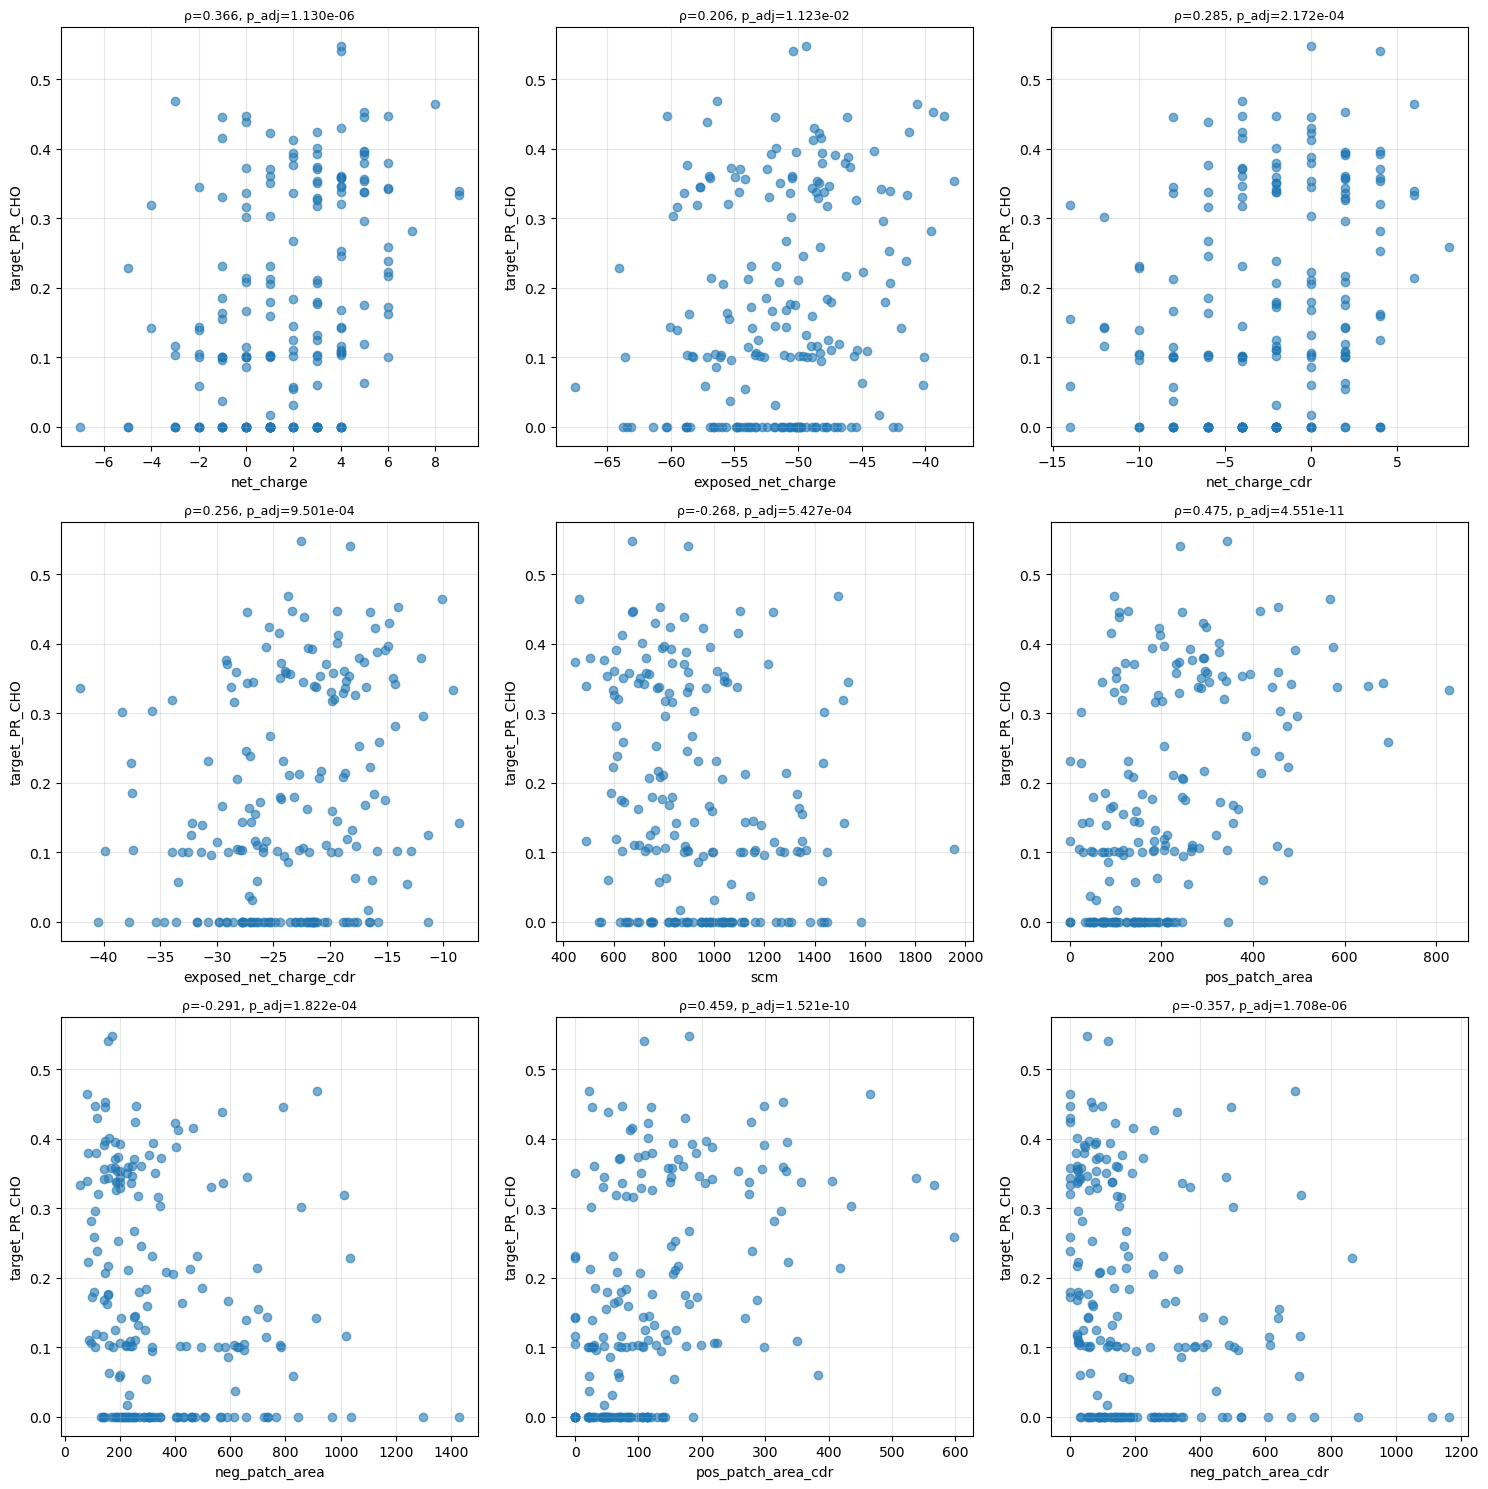

In [97]:
corr_df, significant_corr = calculate_correlations_and_plot(
        GINKGO_propermab_merged, 'target_PR_CHO', p_threshold=0.05, use_fdr=True, normalize=False
    )

In [33]:
# Debug: where are the NaNs? (same feature set as stability_selection with use_all_features=True)
# Set to the same dataset you use for stability selection, e.g. list(corr_by_dataset.keys())[0]
debug_dataset_name = 'ginkgo_unified_target_AC_SINS_pH7_4'  # or e.g. 'ginkgo_unified_target_AC_SINS_pH7_4'

merged_debug, target_col_debug = next(
    (m, tc) for m, tc in merged_dfs
    if "dataset" in m.columns and len(m) > 0 and m["dataset"].iloc[0] == debug_dataset_name
)
exclude_cols = {"target", target_col_debug, "structure_id", "base", "heavy", "light", "name", "dataset", "index"}
numeric_cols = set(merged_debug.select_dtypes(include=[np.number]).columns)
feat_candidates_debug = [c for c in numeric_cols if c not in exclude_cols]

X_debug = merged_debug[feat_candidates_debug].copy()
for c in feat_candidates_debug:
    X_debug[c] = pd.to_numeric(X_debug[c], errors="coerce")
y_debug = pd.to_numeric(merged_debug[target_col_debug], errors="coerce")
mask_valid_y = y_debug.notna()
X_debug = X_debug.loc[mask_valid_y]
n_rows = len(X_debug)

nan_count = X_debug.isna().sum()
nan_frac = (nan_count / n_rows).sort_values(ascending=False)
cols_all_nan = nan_count[nan_count == n_rows].index.tolist()
cols_any_nan = nan_count[nan_count > 0].index.tolist()

print(f"Dataset: {debug_dataset_name}")
print(f"Rows (with valid target): {n_rows}, Features: {len(feat_candidates_debug)}")
print(f"\nColumns that are 100% NaN ({len(cols_all_nan)}): {cols_all_nan}")
print(f"\nColumns with at least one NaN ({len(cols_any_nan)}):")
print(nan_frac[nan_frac > 0].to_string())
print(f"\nRows with at least one NaN in X: {(X_debug.isna().any(axis=1)).sum()} / {n_rows}")

Dataset: ginkgo_unified_target_AC_SINS_pH7_4
Rows (with valid target): 244, Features: 114

Columns that are 100% NaN (0): []

Columns with at least one NaN (1):
ratio_salt_bridges_CDR_to_total    0.852459

Rows with at least one NaN in X: 208 / 244


# Building models

In [ ]:
# Example: stability selection (alternative to reduce_correlated_features)
# dataset_name must be one of list(corr_by_dataset.keys()) (one per target: Jain merged, GINKGO, hutchinson, etc.)
dataset_name_ss = 'ginkgo_unified_target_PR_CHO'  # or set to a specific key, e.g. "jain2024assessment_merged_Fab_Tm_by_DSF_C_Tm"
freq_ss, selected_ss = stability_selection_features(
    dataset_name_ss,
    merged_dfs,
    corr_by_dataset,
    n_subsamples=100,
    sample_fraction=0.5,
    model_type="elasticnet",
    l1_ratio=0.7,
    coef_threshold=1e-3,
    selection_freq_threshold=0.5,
    candidate_features=None,  # or pass kept_features from reduce_correlated_features to use same pool
    random_state=42,
    verbose=True,
    fallback_top_fraction=0.2  # top 20% if nothing passes threshold

)
print("Selection frequency (top 20):")
print(freq_ss.sort_values(ascending=False).head(20))
print(f"Selected features: {selected_ss}")

Stability selection: completed 20/100 subsamples
Stability selection: completed 40/100 subsamples
Stability selection: completed 60/100 subsamples
Stability selection: completed 80/100 subsamples


In [ ]:
kept_from_ss, pairs_ss = reduce_correlated_features_from_set(
    dataset_name,
    merged_dfs,
    corr_by_dataset,
    feature_set=selected_ss,
    correlation_threshold=0.8,
)

In [ ]:
# # Example usage (run after the cell that builds corr_by_dataset):
# # dataset_name must be one of list(corr_by_dataset.keys()) (one per target)
dataset_name = 'ginkgo_unified_target_PR_CHO'  # or set to a specific key
threshold = 0.8
kept_features, pairs = reduce_correlated_features(dataset_name, merged_dfs, corr_by_dataset, correlation_threshold=threshold)
print(f"Kept {len(kept_features)} features: {kept_features}")
if pairs:
    print("Dropped pairs (kept, dropped, feat-feat r, target_r_kept, target_r_dropped):")
    for p in pairs:
        print(p)

Kept 28 features: ['inter_chain_buried_sasa', 'inter_chain_contact_number', 'wcn_beta_sheet_median', 'wcn_buried_median', 'wcn_exposed_median', 'hbond_energy_dssp_density_exposed_median', 'hbond_density_CDRs_mean', 'ratio_hbonds_CDR_to_total', 'fraction_gly_CDRs', 'fraction_pro_CDRs', 'fraction_aromatic_CDRs', 'fraction_gln_asn_CDRs', 'fraction_buried', 'fraction_hydrophobic_buried', 'fraction_gln_asn_beta_sheet', 'polar_cluster_max_total_side_rel', 'hbond_density_inter_chain_mean', 'hbond_energy_dssp_density_inter_chain_median', 'ripley_k_polar', 'psh_cdr_vicinity', 'dipole_moment_magnitude', 'polar_total_side_rel_sum', 'positive_buried_total_side_rel_sum', 'polar_buried_total_side_rel_sum', 'hydrophobic_exposed_total_side_rel_sum', 'polar_inter_chain_total_side_rel_sum', 'hydrophobic_inter_chain_total_side_rel_sum', 'hydrophobic_CDRs_total_side_rel_sum']
Dropped pairs (kept, dropped, feat-feat r, target_r_kept, target_r_dropped):
('fraction_gln_asn_beta_sheet', 'aromatic_CDRs_total_s

Available dataset IDs (one per target): ['ab21.csv', 'garbinski2023_tm1.csv', 'ginkgo_unified_target_Titer', 'ginkgo_unified_target_Purity', 'ginkgo_unified_target_SEC_Monomer', 'ginkgo_unified_target_SMAC', 'ginkgo_unified_target_HIC', 'ginkgo_unified_target_HAC', 'ginkgo_unified_target_PR_CHO', 'ginkgo_unified_target_PR_Ova', 'ginkgo_unified_target_AC_SINS_pH6_0', 'ginkgo_unified_target_AC_SINS_pH7_4', 'ginkgo_unified_target_Tonset', 'ginkgo_unified_target_Tm1', 'ginkgo_unified_target_Tm2', 'hutchinson2023enhancement_top200tm1_igg.csv', 'jain2017biophysical_merged_target_fitness_ACSINS', 'jain2017biophysical_merged_target_fitness_CSIBLI', 'jain2017biophysical_merged_target_fitness_HICRT', 'jain2017biophysical_merged_target_fitness_SAS', 'jain2017biophysical_merged_target_fitness_SGACSINS', 'jain2017biophysical_merged_target_fitness_BVPELISA', 'jain2017biophysical_merged_target_fitness_CICRT', 'jain2017biophysical_merged_target_fitness_ELISA', 'jain2017biophysical_merged_target_fitnes

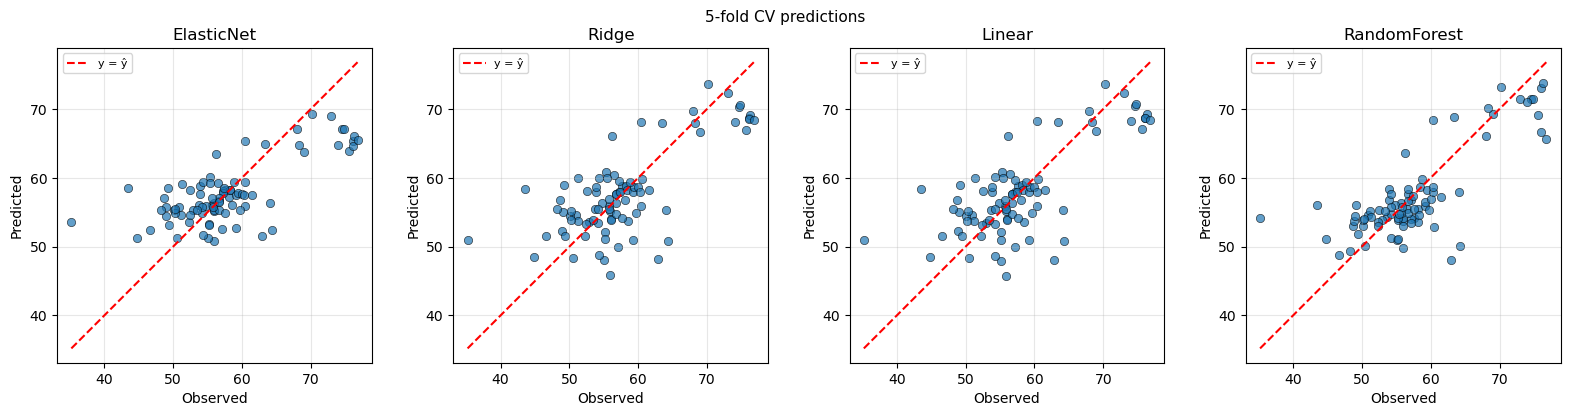

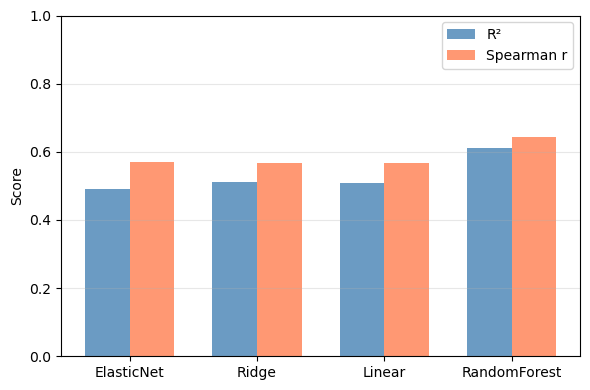

Selected features (by ElasticNet): ['fraction_gln_asn_beta_sheet', 'wcn_exposed_median', 'ripley_k_polar', 'dipole_moment_magnitude']
          model   mean_r2    std_r2  spearman_r    spearman_p  n_features  \
0    ElasticNet  0.491556  0.141358    0.570558  9.740041e-09           4   
1         Ridge  0.511483  0.219214    0.567878  1.182466e-08           4   
2        Linear  0.509293  0.222740    0.566406  1.314428e-08           4   
3  RandomForest  0.610796  0.188940    0.643701  2.310605e-11           4   

   n_samples  
0         86  
1         86  
2         86  
3         86  


In [ ]:
# Single-dataset example: dataset_name must be one of list(corr_by_dataset.keys()).
# Keys are one per target: e.g. jain2024assessment_merged_Fab_Tm_by_DSF_C_Tm, ginkgo_unified_<target_col>, hutchinson2023enhancement_top200tm1_igg.csv
print("Available dataset IDs (one per target):", list(corr_by_dataset.keys()))

dataset_name = 'ginkgo_unified_target_PR_CHO'  # or set to a specific key above
merged, target_col = next((m, tc) for m, tc in merged_dfs if "dataset" in m.columns and len(m) > 0 and m["dataset"].iloc[0] == dataset_name)

selected_features, results_df = fit_and_compare_models(
    merged, target_col, n_splits=5, use_loocv=False,
    max_feature_fraction=0.15,
    feature_list=kept_features  # or use kept_features from reduce_correlated_features
)
print("Selected features (by ElasticNet):", selected_features)
print(results_df)

In [153]:
corr_by_dataset.keys()

dict_keys(['ab21.csv', 'garbinski2023_tm1.csv', 'ginkgo_unified_target_Titer', 'ginkgo_unified_target_Purity', 'ginkgo_unified_target_SEC_Monomer', 'ginkgo_unified_target_SMAC', 'ginkgo_unified_target_HIC', 'ginkgo_unified_target_HAC', 'ginkgo_unified_target_PR_CHO', 'ginkgo_unified_target_PR_Ova', 'ginkgo_unified_target_AC_SINS_pH6_0', 'ginkgo_unified_target_AC_SINS_pH7_4', 'ginkgo_unified_target_Tonset', 'ginkgo_unified_target_Tm1', 'ginkgo_unified_target_Tm2', 'hutchinson2023enhancement_top200tm1_igg.csv', 'jain2017biophysical_merged_target_fitness_ACSINS', 'jain2017biophysical_merged_target_fitness_CSIBLI', 'jain2017biophysical_merged_target_fitness_HICRT', 'jain2017biophysical_merged_target_fitness_SAS', 'jain2017biophysical_merged_target_fitness_SGACSINS', 'jain2017biophysical_merged_target_fitness_BVPELISA', 'jain2017biophysical_merged_target_fitness_CICRT', 'jain2017biophysical_merged_target_fitness_ELISA', 'jain2017biophysical_merged_target_fitness_PSR', 'jain2017biophysical_m

In [154]:
datasets_to_check = ['jain2017biophysical_merged_target_fitness_ACSINS', 'jain2017biophysical_merged_target_fitness_CSIBLI', 'jain2017biophysical_merged_target_fitness_HICRT', 'jain2017biophysical_merged_target_fitness_SAS', 'jain2017biophysical_merged_target_fitness_SGACSINS', 'jain2017biophysical_merged_target_fitness_BVPELISA', 'jain2017biophysical_merged_target_fitness_CICRT', 'jain2017biophysical_merged_target_fitness_ELISA', 'jain2017biophysical_merged_target_fitness_PSR', 'jain2017biophysical_merged_target_fitness_SMACRT', 'jain2017biophysical_merged_target_fitness_Tm', 'jain2023identifying_merged_target_fitness_DNP', 'jain2023identifying_merged_target_fitness_FA2', 'jain2023identifying_merged_target_fitness_FVC32', 'jain2023identifying_merged_target_fitness_FvFVIII2', 'jain2023identifying_merged_target_fitness_FvLysM2', 'jain2023identifying_merged_target_fitness_Heme2', 'jain2023identifying_merged_target_fitness_HemeC32', 'jain2023identifying_merged_target_fitness_HemeFVIII2', 'jain2023identifying_merged_target_fitness_HemeLysM2', 'jain2024assessment_merged_target_AC_SINS_λmax_nm_ACSINS', 'jain2024assessment_merged_target_CIC_Column_K_CIC', 'jain2024assessment_merged_target_CS_SINS_ave_CSSINS', 'jain2024assessment_merged_target_Fab_pI_Fab_pI', 'jain2024assessment_merged_target_HIC_RT_min_HIC', 'jain2024assessment_merged_target_SEC_Monomer_SEC', 'jain2024assessment_merged_target_cIEF_Main_peak_cIEF', 'jain2024assessment_merged_target_Heparin_Column_Rel_RT_Herapin_RT', 'jain2024assessment_merged_target_PSR_PSR', 'jain2024assessment_merged_target_Fab_Tm_by_DSF_C_Tm']

In [ ]:
# Run stability selection + model comparison for every dataset in corr_by_dataset

all_results = {}          # raw Python objects (Series, lists, DataFrames)
all_results_json_like = {}  # JSON-friendly version (Series/DataFrames converted)
all_model_rows = []       # to build one big results DataFrame

# for dataset_name_ss in corr_by_dataset.keys():
for dataset_name_ss in datasets_to_check:

    print(f"\n=== Processing dataset: {dataset_name_ss} ===")
    try:
        # 1) Stability selection on this dataset
        freq_ss, selected_ss = stability_selection_features(
            dataset_name_ss,
            merged_dfs,
            corr_by_dataset,
            n_subsamples=100,
            sample_fraction=0.5,
            model_type="elasticnet",
            l1_ratio=0.7,
            coef_threshold=1e-3,
            selection_freq_threshold=0.5,
            candidate_features=None,   # or pass kept_features if you want
            random_state=42,
            verbose=False,             # set True if you want per-iteration logging
        )

        print(f"  Stability selection picked {len(selected_ss)} features.")

        # 2) Get merged df + target column for this dataset
        merged, target_col = next(
            (m, tc)
            for m, tc in merged_dfs
            if "dataset" in m.columns
            and len(m) > 0
            and m["dataset"].iloc[0] == dataset_name_ss
        )

        # 3) Fit models using only the stability-selected features
        selected_features, results_df = fit_and_compare_models(
            merged,
            target_col,
            n_splits=5,
            use_loocv=False,
            max_feature_fraction=0.15,
            feature_list=selected_ss,
        )

        print(f"  fit_and_compare_models selected {len(selected_features)} features.")

        # Tag results with dataset name
        results_df = results_df.copy()
        results_df["dataset_name"] = dataset_name_ss

        # Store raw objects
        all_results[dataset_name_ss] = {
            "selection_freq": freq_ss,          # pd.Series
            "selected_ss": selected_ss,         # list from stability selection
            "selected_features": selected_features,  # list from fit_and_compare_models
            "results_df": results_df,           # per-dataset model comparison
        }

        # Store JSON-like version (no saving, just in-memory)
        all_results_json_like[dataset_name_ss] = {
            "selection_freq": freq_ss.to_dict(),
            "selected_ss": selected_ss,
            "selected_features": selected_features,
            "results": results_df.to_dict(orient="records"),
        }

        all_model_rows.append(results_df)

    except StopIteration:
        print(f"  Skipping {dataset_name_ss}: no matching (merged_df, target_col) in merged_dfs.")
    except Exception as e:
        print(f"  Error processing {dataset_name_ss}: {e}")

# Combined results across all datasets (one DataFrame)
if all_model_rows:
    all_results_df = pd.concat(all_model_rows, ignore_index=True)
else:
    all_results_df = pd.DataFrame()

print("\nDone. Objects created:")
print("  all_results            # per-dataset raw objects")
print("  all_results_json_like  # per-dataset JSON-friendly dict")
print("  all_results_df         # combined model comparison DataFrame")

In [156]:
all_results            

{'jain2017biophysical_merged_target_fitness_ACSINS': {'selection_freq': inter_chain_buried_sasa                          0.00
  hbond_energy_dssp_density_median                 0.07
  fraction_gln_asn_beta_sheet                      0.02
  ripley_k_negative                                0.03
  n_hydrogen_bonds                                 0.06
  hbond_density_CDRs_mean                          0.03
  total_side_rel_median                            0.02
  fraction_hydrophobic_buried                      0.00
  aromatic_buried_total_side_rel_sum               0.01
  hbond_energy_dssp_density_beta_sheet_median      0.02
  hbond_density_inter_chain_mean                   0.24
  ripley_k_positive                                0.00
  polar_CDRs_total_side_rel_sum                    0.00
  wcn_buried_median                                0.02
  positive_exposed_total_side_rel_sum              0.02
  wcn_median                                       0.01
  fraction_hydrophobic_exposed    

In [128]:
# Debug stability-selection feature candidates for one dataset (e.g. SMAC)
debug_dataset = "ginkgo_unified_target_SMAC"

print(f"=== Debugging feature candidates for: {debug_dataset} ===")

# 1) Locate merged df and target column
merged_dbg = None
target_col_dbg = None
for m, tc in merged_dfs:
    if "dataset" in m.columns and len(m) > 0 and m["dataset"].iloc[0] == debug_dataset:
        merged_dbg = m
        target_col_dbg = tc
        break

if merged_dbg is None:
    print("No merged dataframe found for this dataset.")
else:
    print(f"Found merged_df with shape: {merged_dbg.shape}, target_col: {target_col_dbg}")

    # 2) Reproduce candidate feature selection logic from stability_selection_features
    exclude_cols = {
        "target", target_col_dbg, "structure_id", "base", "heavy",
        "light", "name", "dataset", "index"
    }

    numeric_cols = set(merged_dbg.select_dtypes(include=[np.number]).columns)
    feat_candidates = [c for c in numeric_cols if c not in exclude_cols]

    print(f"Total numeric cols: {len(numeric_cols)}")
    print(f"Initial candidate features (before NaN-drop): {len(feat_candidates)}")
    if len(feat_candidates) <= 20:
        print("Candidates:", feat_candidates)

    # 3) Show which of these are all-NaN
    X_dbg = merged_dbg[feat_candidates].copy()
    for c in feat_candidates:
        X_dbg[c] = pd.to_numeric(X_dbg[c], errors="coerce")
    all_nan_cols = X_dbg.columns[X_dbg.isna().all()].tolist()

    print(f"Columns that are 100% NaN among candidates: {len(all_nan_cols)}")
    if all_nan_cols:
        print("All-NaN candidates:", all_nan_cols)

    # 4) Effective candidates after dropping all-NaN
    effective_candidates = [c for c in feat_candidates if c not in all_nan_cols]
    print(f"Effective candidate features after dropping all-NaN: {len(effective_candidates)}")
    if len(effective_candidates) <= 20:
        print("Effective candidates:", effective_candidates)

    # 5) Quick check: what happens if we call stability_selection_features?
    try:
        freq_dbg, selected_dbg = stability_selection_features(
            debug_dataset,
            merged_dfs,
            corr_by_dataset,
            n_subsamples=10,         # smaller for debug
            sample_fraction=0.5,
            model_type="elasticnet",
            l1_ratio=0.7,
            coef_threshold=1e-3,
            selection_freq_threshold=0.5,
            candidate_features=None,
            random_state=42,
            verbose=False,
        )
        print(f"\nstability_selection_features returned {len(selected_dbg)} selected features.")
        if len(selected_dbg) <= 20:
            print("Selected features:", selected_dbg)
    except Exception as e:
        print("\nError when running stability_selection_features:", e)

=== Debugging feature candidates for: ginkgo_unified_target_SMAC ===
Found merged_df with shape: (244, 122), target_col: target_SMAC
Total numeric cols: 116
Initial candidate features (before NaN-drop): 114
Columns that are 100% NaN among candidates: 0
Effective candidate features after dropping all-NaN: 114

stability_selection_features returned 0 selected features.
Selected features: []
